📂 Upload  Crop_recommendation_dataset.csv


Saving Crop recommendation dataset.csv to Crop recommendation dataset.csv
✅ Loaded : 57,000 rows × 7 columns
✅ Filtered : 16,000 rows | 16 classes

  TRAINING MODELS ...

🔄  Random Forest ... done (1.6s)

🔄  Decision Tree ... done (0.1s)

🔄  Logistic Regression ... done (2.7s)

🔄  KNN ... done (0.2s)

🔄  SVM ... done (8.2s)


══════════════════════════════════════════════════════════════════════
  TABLE 1 — OVERALL PERFORMANCE METRICS (All 5 Models)
══════════════════════════════════════════════════════════════════════
                     Accuracy (%)  Precision % (Macro)  Recall % (Macro)  F1-Score % (Macro)  ROC AUC (Macro)
Model                                                                                                        
Random Forest             93.4700              93.6800           93.4700             93.3000           0.9948
Decision Tree             90.0000              90.0300           90.0000             90.0000           0.9467
Logistic Regression       82.7200  

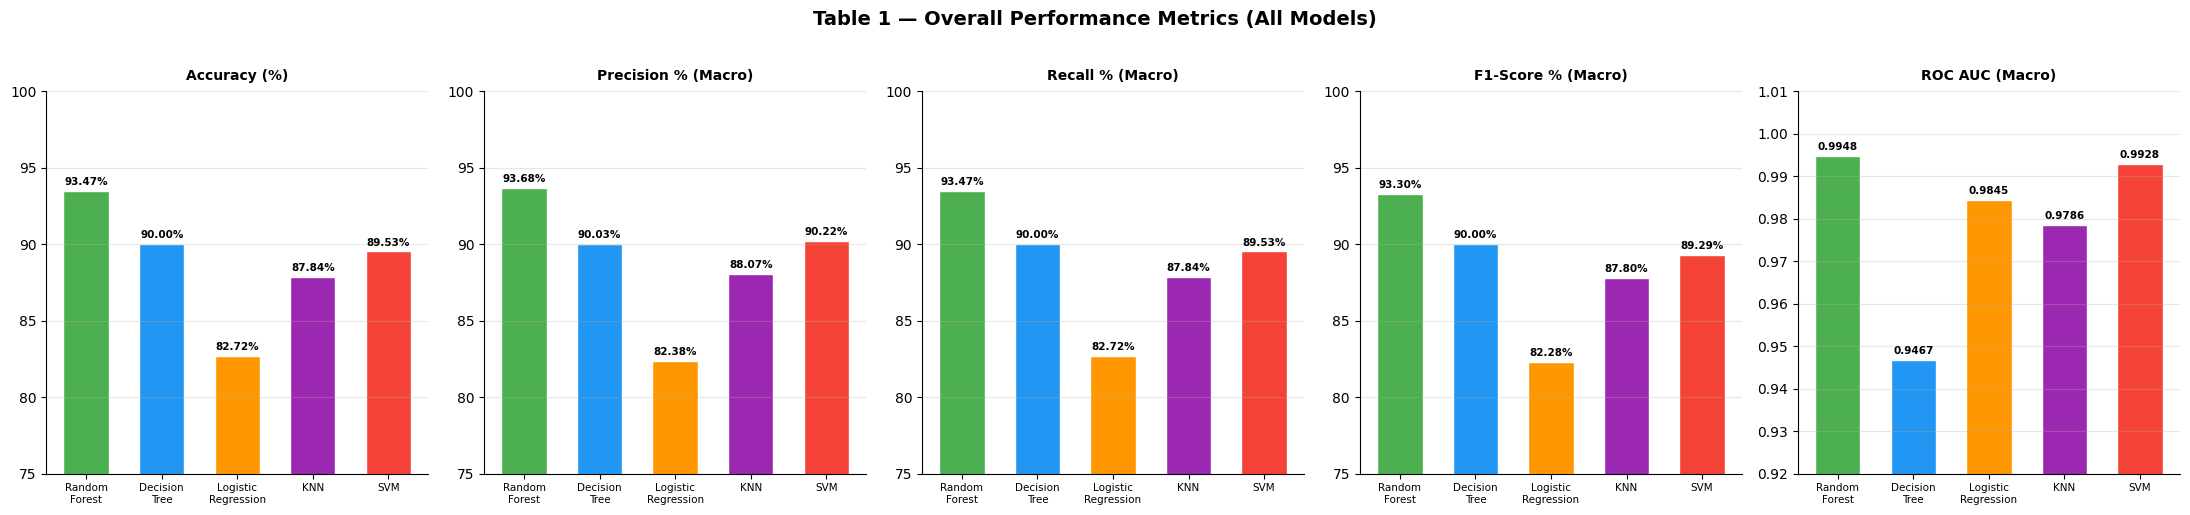

✅  Saved : table1_metrics_bar.png


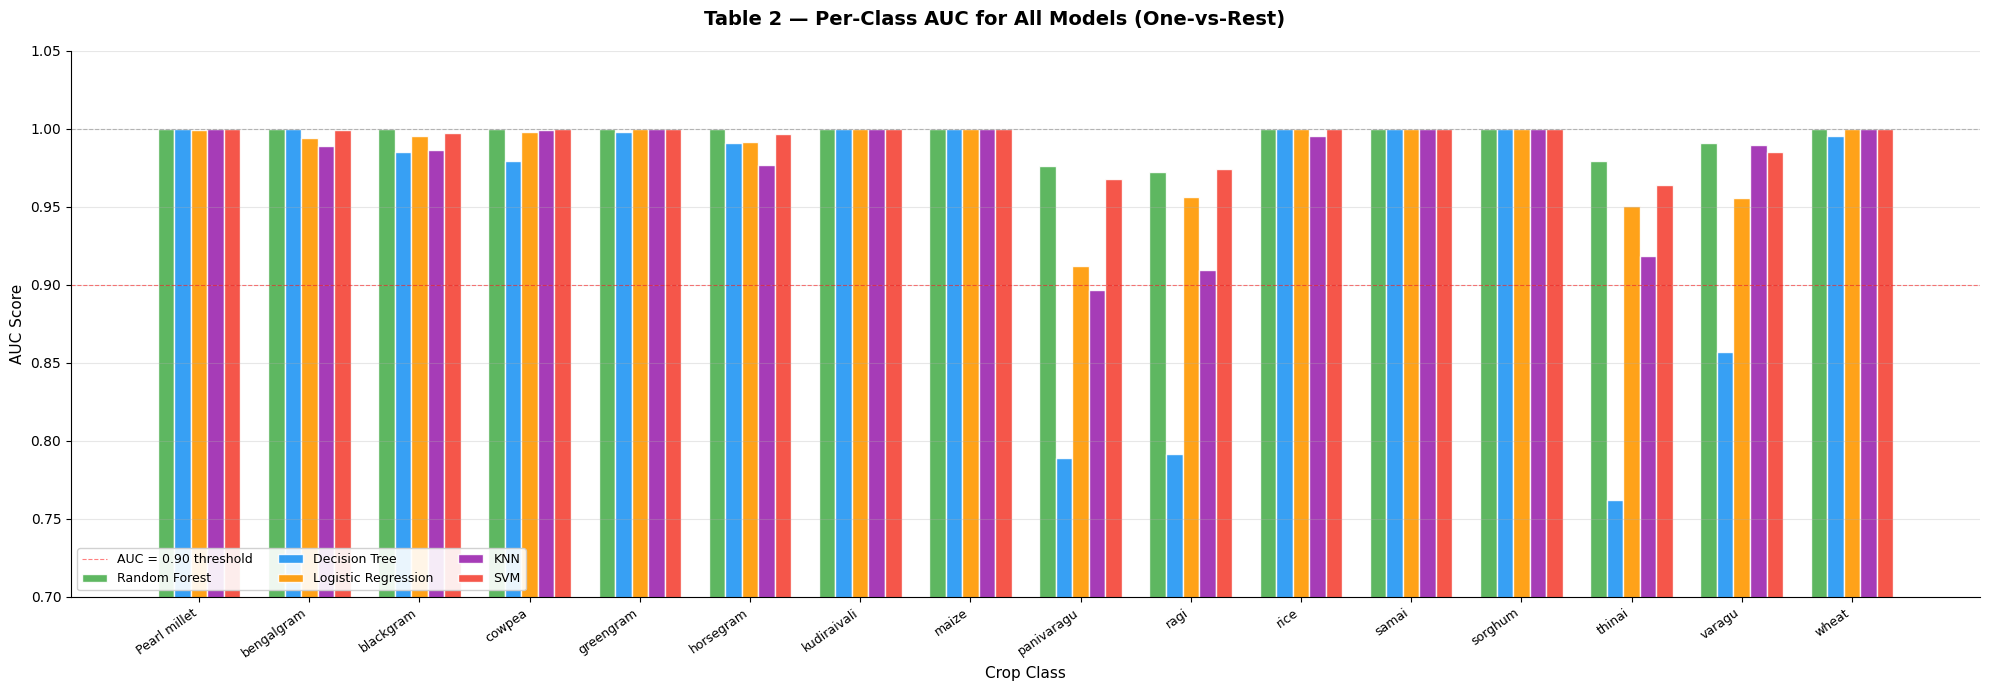

✅  Saved : table2_perclass_auc_bar.png


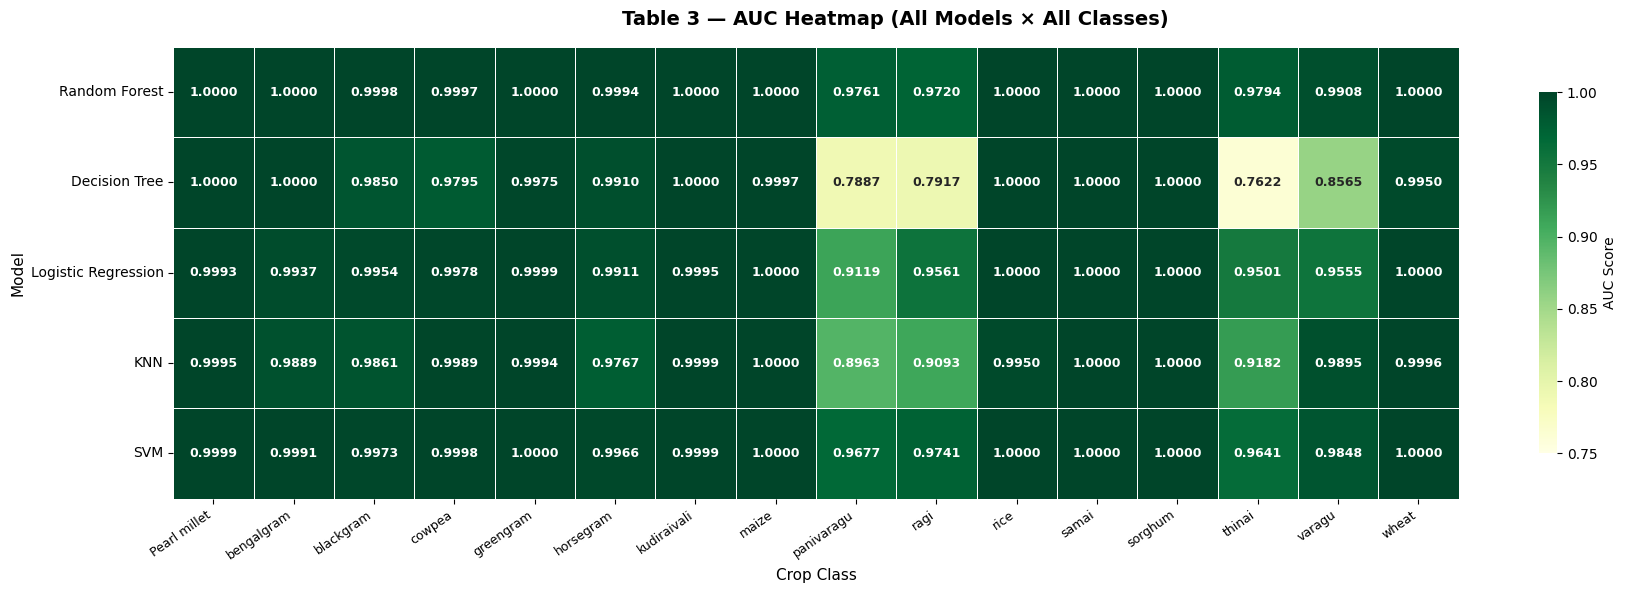

✅  Saved : table3_auc_heatmap.png


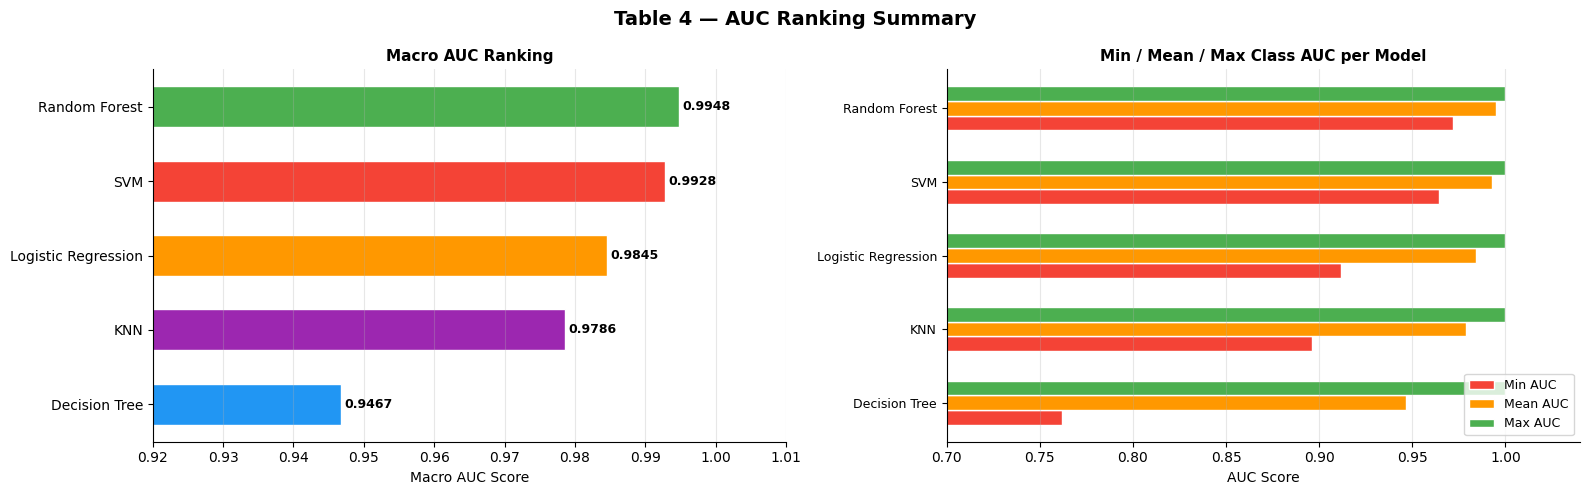

✅  Saved : table4_auc_ranking.png

✅  Saved : all_auc_tables.xlsx  (5 sheets)
✅  Saved : table1_overall_metrics.csv
✅  Saved : table3_auc_matrix.csv
✅  Saved : table4_auc_ranking.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉  Done!  8 files downloaded.


  FINAL SUMMARY — ALL TABLES

TABLE 1 — Overall Metrics:
                     Accuracy (%)  Precision % (Macro)  Recall % (Macro)  F1-Score % (Macro)  ROC AUC (Macro)
Model                                                                                                        
Random Forest             93.4700              93.6800           93.4700             93.3000           0.9948
Decision Tree             90.0000              90.0300           90.0000             90.0000           0.9467
Logistic Regression       82.7200              82.3800           82.7200             82.2800           0.9845
KNN                       87.8400              88.0700           87.8400             87.8000           0.9786
SVM                       89.5300              90.2200           89.5300             89.2900           0.9928

TABLE 3 — AUC Matrix (rows=models, cols=crops):
Crop Class           Pearl millet  bengalgram  blackgram  cowpea  greengram  horsegram  kud

In [1]:
# ================================================================
# ROC & AUC TABLE VALUES — 16 CROP CLASSES
# Dataset : Crop_recommendation_dataset.csv
# Models  : Random Forest, Decision Tree, Logistic Regression,
#           KNN, SVM
# Output  : Table 1 — Overall Metrics (Acc, Prec, Rec, F1, AUC)
#           Table 2 — Per-Class AUC for each model
#           Table 3 — Combined AUC heatmap (all models × classes)
#           Table 4 — AUC Ranking summary
#           + All tables saved as CSV + Excel
# ================================================================

# ── STEP 1 : Libraries ───────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics         import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      roc_curve, auc)
from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC

# ── STEP 2 : Upload & load ───────────────────────────────────
from google.colab import files
print("📂 Upload  Crop_recommendation_dataset.csv")
uploaded = files.upload()

import io
fname   = list(uploaded.keys())[0]
df_full = pd.read_csv(io.BytesIO(uploaded[fname]))
print(f"✅ Loaded : {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# ── STEP 3 : Filter to 16 classes ───────────────────────────
SELECTED = [
    'rice','wheat','maize','sorghum','Pearl millet',
    'ragi','panivaragu','samai','thinai','varagu',
    'kudiraivali','blackgram','greengram','cowpea',
    'bengalgram','horsegram'
]
df = df_full[df_full['CROPS'].isin(SELECTED)].copy().reset_index(drop=True)
print(f"✅ Filtered : {df.shape[0]:,} rows | {df['CROPS'].nunique()} classes\n")

# ── STEP 4 : Preprocessing ───────────────────────────────────
FEATURES = ['SOIL_PH','TEMP','RELATIVE_HUMIDITY','N','P','K']
le        = LabelEncoder()
y         = le.fit_transform(df['CROPS'])
X         = df[FEATURES]

class_names = le.classes_
n_classes   = len(class_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
y_test_bin  = label_binarize(y_test, classes=np.arange(n_classes))

# ── STEP 5 : Models ──────────────────────────────────────────
MODELS = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN'                : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
}
USE_SCALED = {'Logistic Regression','KNN','SVM'}

COLORS = {
    'Random Forest'      : '#4CAF50',
    'Decision Tree'      : '#2196F3',
    'Logistic Regression': '#FF9800',
    'KNN'                : '#9C27B0',
    'SVM'                : '#F44336',
}

# ── STEP 6 : Train & compute all ROC / AUC values ────────────
overall_rows  = []
perclass_data = {}   # model → {class: auc}

print("="*70)
print("  TRAINING MODELS ...")
print("="*70)

for name, model in MODELS.items():
    Xtr = X_train_sc if name in USE_SCALED else X_train.values
    Xte = X_test_sc  if name in USE_SCALED else X_test.values

    t0 = time.time()
    print(f"\n🔄  {name} ...", end=" ", flush=True)
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_score = model.predict_proba(Xte)
    print(f"done ({time.time()-t0:.1f}s)")

    # ── Overall metrics ──────────────────────────────────────
    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score   (y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score       (y_test, y_pred, average='macro', zero_division=0)

    # ── Per-class AUC ────────────────────────────────────────
    fpr_d, tpr_d, auc_d = {}, {}, {}
    for i in range(n_classes):
        fpr_d[i], tpr_d[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc_d[i] = round(auc(fpr_d[i], tpr_d[i]), 4)

    # ── Macro AUC ────────────────────────────────────────────
    all_fpr  = np.unique(np.concatenate([fpr_d[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_d[i], tpr_d[i])
    mean_tpr    /= n_classes
    macro_auc    = round(auc(all_fpr, mean_tpr), 4)

    overall_rows.append({
        'Model'              : name,
        'Accuracy (%)'       : round(acc*100, 2),
        'Precision % (Macro)': round(prec*100, 2),
        'Recall % (Macro)'   : round(rec*100, 2),
        'F1-Score % (Macro)' : round(f1*100, 2),
        'ROC AUC (Macro)'    : macro_auc,
    })
    perclass_data[name] = {class_names[i]: auc_d[i] for i in range(n_classes)}

# ════════════════════════════════════════════════════════════
# TABLE 1 — Overall Performance Metrics
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*70)
print("  TABLE 1 — OVERALL PERFORMANCE METRICS (All 5 Models)")
print("═"*70)

df_overall = pd.DataFrame(overall_rows).set_index('Model')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
print(df_overall.to_string())

best_model = df_overall['Accuracy (%)'].idxmax()
print(f"\n🏆  Best model : {best_model}  →  Accuracy {df_overall.loc[best_model,'Accuracy (%)']}%"
      f"  |  AUC {df_overall.loc[best_model,'ROC AUC (Macro)']}")

# ════════════════════════════════════════════════════════════
# TABLE 2 — Per-Class AUC for EACH model (separate table)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*70)
print("  TABLE 2 — PER-CLASS AUC (One-vs-Rest) — Each Model")
print("═"*70)

for name in MODELS:
    print(f"\n{'─'*50}")
    print(f"  Model : {name}")
    print(f"{'─'*50}")
    rows = []
    for i, cls in enumerate(class_names):
        v = perclass_data[name][cls]
        if   v >= 0.99: grade = "Excellent"
        elif v >= 0.97: grade = "Very Good"
        elif v >= 0.93: grade = "Good"
        elif v >= 0.85: grade = "Fair"
        else:           grade = "Low"
        rows.append({'#': i+1, 'Crop Class': cls, 'AUC Score': v, 'Grade': grade})
    df_cls = pd.DataFrame(rows).set_index('#')
    print(df_cls.to_string())
    avg = np.mean(list(perclass_data[name].values()))
    print(f"\n  → Mean AUC : {avg:.4f}  |  "
          f"Min : {min(perclass_data[name].values()):.4f}  |  "
          f"Max : {max(perclass_data[name].values()):.4f}")

# ════════════════════════════════════════════════════════════
# TABLE 3 — Combined AUC Matrix (all models × all classes)
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*70)
print("  TABLE 3 — COMBINED AUC MATRIX (All Models × All Classes)")
print("═"*70)

df_matrix = pd.DataFrame(perclass_data).T          # rows=models, cols=classes
df_matrix.index.name   = 'Model'
df_matrix.columns.name = 'Crop Class'
print(df_matrix.to_string())

print("\n  Column stats (per crop):")
print(df_matrix.describe().loc[['mean','min','max']].to_string())

# ════════════════════════════════════════════════════════════
# TABLE 4 — AUC Ranking Summary
# ════════════════════════════════════════════════════════════
print("\n\n" + "═"*70)
print("  TABLE 4 — AUC RANKING SUMMARY")
print("═"*70)

rank_rows = []
for name in MODELS:
    vals = list(perclass_data[name].values())
    rank_rows.append({
        'Model'          : name,
        'Macro AUC'      : df_overall.loc[name, 'ROC AUC (Macro)'],
        'Mean Class AUC' : round(np.mean(vals), 4),
        'Min Class AUC'  : round(min(vals), 4),
        'Max Class AUC'  : round(max(vals), 4),
        'Classes AUC>=0.99': sum(1 for v in vals if v >= 0.99),
        'Classes AUC<0.90' : sum(1 for v in vals if v <  0.90),
    })

df_rank = (pd.DataFrame(rank_rows)
             .set_index('Model')
             .sort_values('Macro AUC', ascending=False))
df_rank.insert(0, 'Rank', range(1, len(df_rank)+1))
print(df_rank.to_string())

# ════════════════════════════════════════════════════════════
# FIGURE 1 — Metrics bar chart
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Table 1 — Overall Performance Metrics (All Models)",
             fontsize=14, fontweight='bold', y=1.02)

metrics = ['Accuracy (%)','Precision % (Macro)','Recall % (Macro)',
           'F1-Score % (Macro)','ROC AUC (Macro)']
ylims   = [(75,100),(75,100),(75,100),(75,100),(0.92,1.01)]
palette = [COLORS[m] for m in df_overall.index]

for ax, metric, ylim in zip(axes, metrics, ylims):
    vals = df_overall[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=palette,
                  edgecolor='white', width=0.6)
    ax.set_title(metric, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylim(ylim)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([m.replace(' ','\n') for m in vals.index],
                       fontsize=7.5, ha='center')
    for bar, v in zip(bars, vals.values):
        label = f'{v:.4f}' if metric == 'ROC AUC (Macro)' else f'{v:.2f}%'
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (ylim[1]-ylim[0])*0.01,
                label, ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('table1_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved : table1_metrics_bar.png")

# ════════════════════════════════════════════════════════════
# FIGURE 2 — Per-class AUC grouped bar chart
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(20, 7))
fig.suptitle("Table 2 — Per-Class AUC for All Models (One-vs-Rest)",
             fontsize=14, fontweight='bold')

x      = np.arange(n_classes)
width  = 0.15
model_list = list(MODELS.keys())

for i, name in enumerate(model_list):
    vals = [perclass_data[name][cls] for cls in class_names]
    offset = (i - 2) * width
    bars = ax.bar(x + offset, vals, width,
                  label=name, color=COLORS[name], edgecolor='white', alpha=0.9)

ax.set_xlabel('Crop Class', fontsize=11)
ax.set_ylabel('AUC Score', fontsize=11)
ax.set_ylim([0.70, 1.05])
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=9)
ax.axhline(y=1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.axhline(y=0.90, color='red', lw=0.8, linestyle='--', alpha=0.5,
           label='AUC = 0.90 threshold')
ax.legend(loc='lower left', fontsize=9, ncol=3, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('table2_perclass_auc_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved : table2_perclass_auc_bar.png")

# ════════════════════════════════════════════════════════════
# FIGURE 3 — AUC Heatmap (Table 3)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle("Table 3 — AUC Heatmap (All Models × All Classes)",
             fontsize=14, fontweight='bold')

sns.heatmap(
    df_matrix.astype(float),
    annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.75, vmax=1.0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    ax=ax, cbar_kws={'label': 'AUC Score', 'shrink': 0.8}
)
ax.set_xlabel('Crop Class', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('table3_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved : table3_auc_heatmap.png")

# ════════════════════════════════════════════════════════════
# FIGURE 4 — AUC Ranking bar (Table 4)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Table 4 — AUC Ranking Summary", fontsize=14, fontweight='bold')

sorted_models = df_rank.sort_values('Macro AUC', ascending=True).index.tolist()

# Left — Macro AUC
ax = axes[0]
vals   = [df_overall.loc[m,'ROC AUC (Macro)'] for m in sorted_models]
colors = [COLORS[m] for m in sorted_models]
bars   = ax.barh(sorted_models, vals, color=colors, edgecolor='white', height=0.55)
ax.set_xlim([0.92, 1.01])
ax.set_xlabel('Macro AUC Score', fontsize=10)
ax.set_title('Macro AUC Ranking', fontsize=11, fontweight='bold')
for bar, v in zip(bars, vals):
    ax.text(v + 0.0005, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Right — Min vs Max class AUC
ax2 = axes[1]
x2  = np.arange(len(sorted_models))
min_vals = [df_rank.loc[m,'Min Class AUC'] for m in sorted_models]
max_vals = [df_rank.loc[m,'Max Class AUC'] for m in sorted_models]
mean_vals= [df_rank.loc[m,'Mean Class AUC'] for m in sorted_models]

ax2.barh(x2-0.2, min_vals,  0.2, label='Min AUC',  color='#F44336', edgecolor='white')
ax2.barh(x2,     mean_vals, 0.2, label='Mean AUC', color='#FF9800', edgecolor='white')
ax2.barh(x2+0.2, max_vals,  0.2, label='Max AUC',  color='#4CAF50', edgecolor='white')
ax2.set_xlim([0.70, 1.04])
ax2.set_yticks(x2)
ax2.set_yticklabels(sorted_models, fontsize=9)
ax2.set_xlabel('AUC Score', fontsize=10)
ax2.set_title('Min / Mean / Max Class AUC per Model', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('table4_auc_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved : table4_auc_ranking.png")

# ════════════════════════════════════════════════════════════
# SAVE ALL TABLES AS CSV + EXCEL
# ════════════════════════════════════════════════════════════
df_overall.to_csv('table1_overall_metrics.csv')
df_matrix.to_csv('table3_auc_matrix.csv')
df_rank.to_csv('table4_auc_ranking.csv')

# Per-class AUC — one sheet per model in Excel
with pd.ExcelWriter('all_auc_tables.xlsx', engine='openpyxl') as writer:
    df_overall.to_excel(writer, sheet_name='Table1_Overall_Metrics')
    for name in MODELS:
        rows = []
        for cls in class_names:
            v = perclass_data[name][cls]
            grade = ("Excellent" if v>=0.99 else
                     "Very Good" if v>=0.97 else
                     "Good"      if v>=0.93 else
                     "Fair"      if v>=0.85 else "Low")
            rows.append({'Crop Class': cls, 'AUC Score': v, 'Grade': grade})
        sheet = name[:28].replace(' ','_')   # Excel sheet name limit
        pd.DataFrame(rows).set_index('Crop Class').to_excel(writer, sheet_name=f'T2_{sheet}')
    df_matrix.to_excel(writer, sheet_name='Table3_AUC_Matrix')
    df_rank.to_excel(writer, sheet_name='Table4_AUC_Ranking')

print("\n✅  Saved : all_auc_tables.xlsx  (5 sheets)")
print("✅  Saved : table1_overall_metrics.csv")
print("✅  Saved : table3_auc_matrix.csv")
print("✅  Saved : table4_auc_ranking.csv")

# ── Download all ─────────────────────────────────────────────
OUTPUT = [
    'table1_metrics_bar.png',
    'table2_perclass_auc_bar.png',
    'table3_auc_heatmap.png',
    'table4_auc_ranking.png',
    'all_auc_tables.xlsx',
    'table1_overall_metrics.csv',
    'table3_auc_matrix.csv',
    'table4_auc_ranking.csv',
]
for f in OUTPUT:
    files.download(f)

print(f"\n🎉  Done!  {len(OUTPUT)} files downloaded.")

# ── Final print ──────────────────────────────────────────────
print("\n\n" + "="*70)
print("  FINAL SUMMARY — ALL TABLES")
print("="*70)
print("\nTABLE 1 — Overall Metrics:")
print(df_overall.to_string())
print("\nTABLE 3 — AUC Matrix (rows=models, cols=crops):")
print(df_matrix.to_string())
print("\nTABLE 4 — AUC Ranking:")
print(df_rank.to_string())

📂  Upload  Crop_recommendation_dataset.csv


Saving Crop recommendation dataset.csv to Crop recommendation dataset (1).csv

✅  Loaded  →  57,000 rows × 7 columns

═════════════════════════════════════════════════════════════════
  DATASET OVERVIEW
═════════════════════════════════════════════════════════════════
  Total rows       : 16,000
  Features         : ['SOIL_PH', 'TEMP', 'RELATIVE_HUMIDITY', 'N', 'P', 'K']
  Target           : CROPS  (16 classes)
  Missing values   : 0
  Samples/class    : 1000 (perfectly balanced)

  Statistical Summary:
         SOIL_PH       TEMP  RELATIVE_HUMIDITY          N          P          K
count 16000.0000 16000.0000         16000.0000 16000.0000 16000.0000 16000.0000
mean      6.5920    26.5510            46.5770    55.5980    35.0340    35.0280
std       0.8160     6.5610            27.7920    32.3280    14.5320    14.6350
min       5.0000    10.0000            15.0000    20.0000    20.0000    20.0000
25%       6.0000    21.8000            17.7000    34.8000    24.8000    24.7000
50%       6

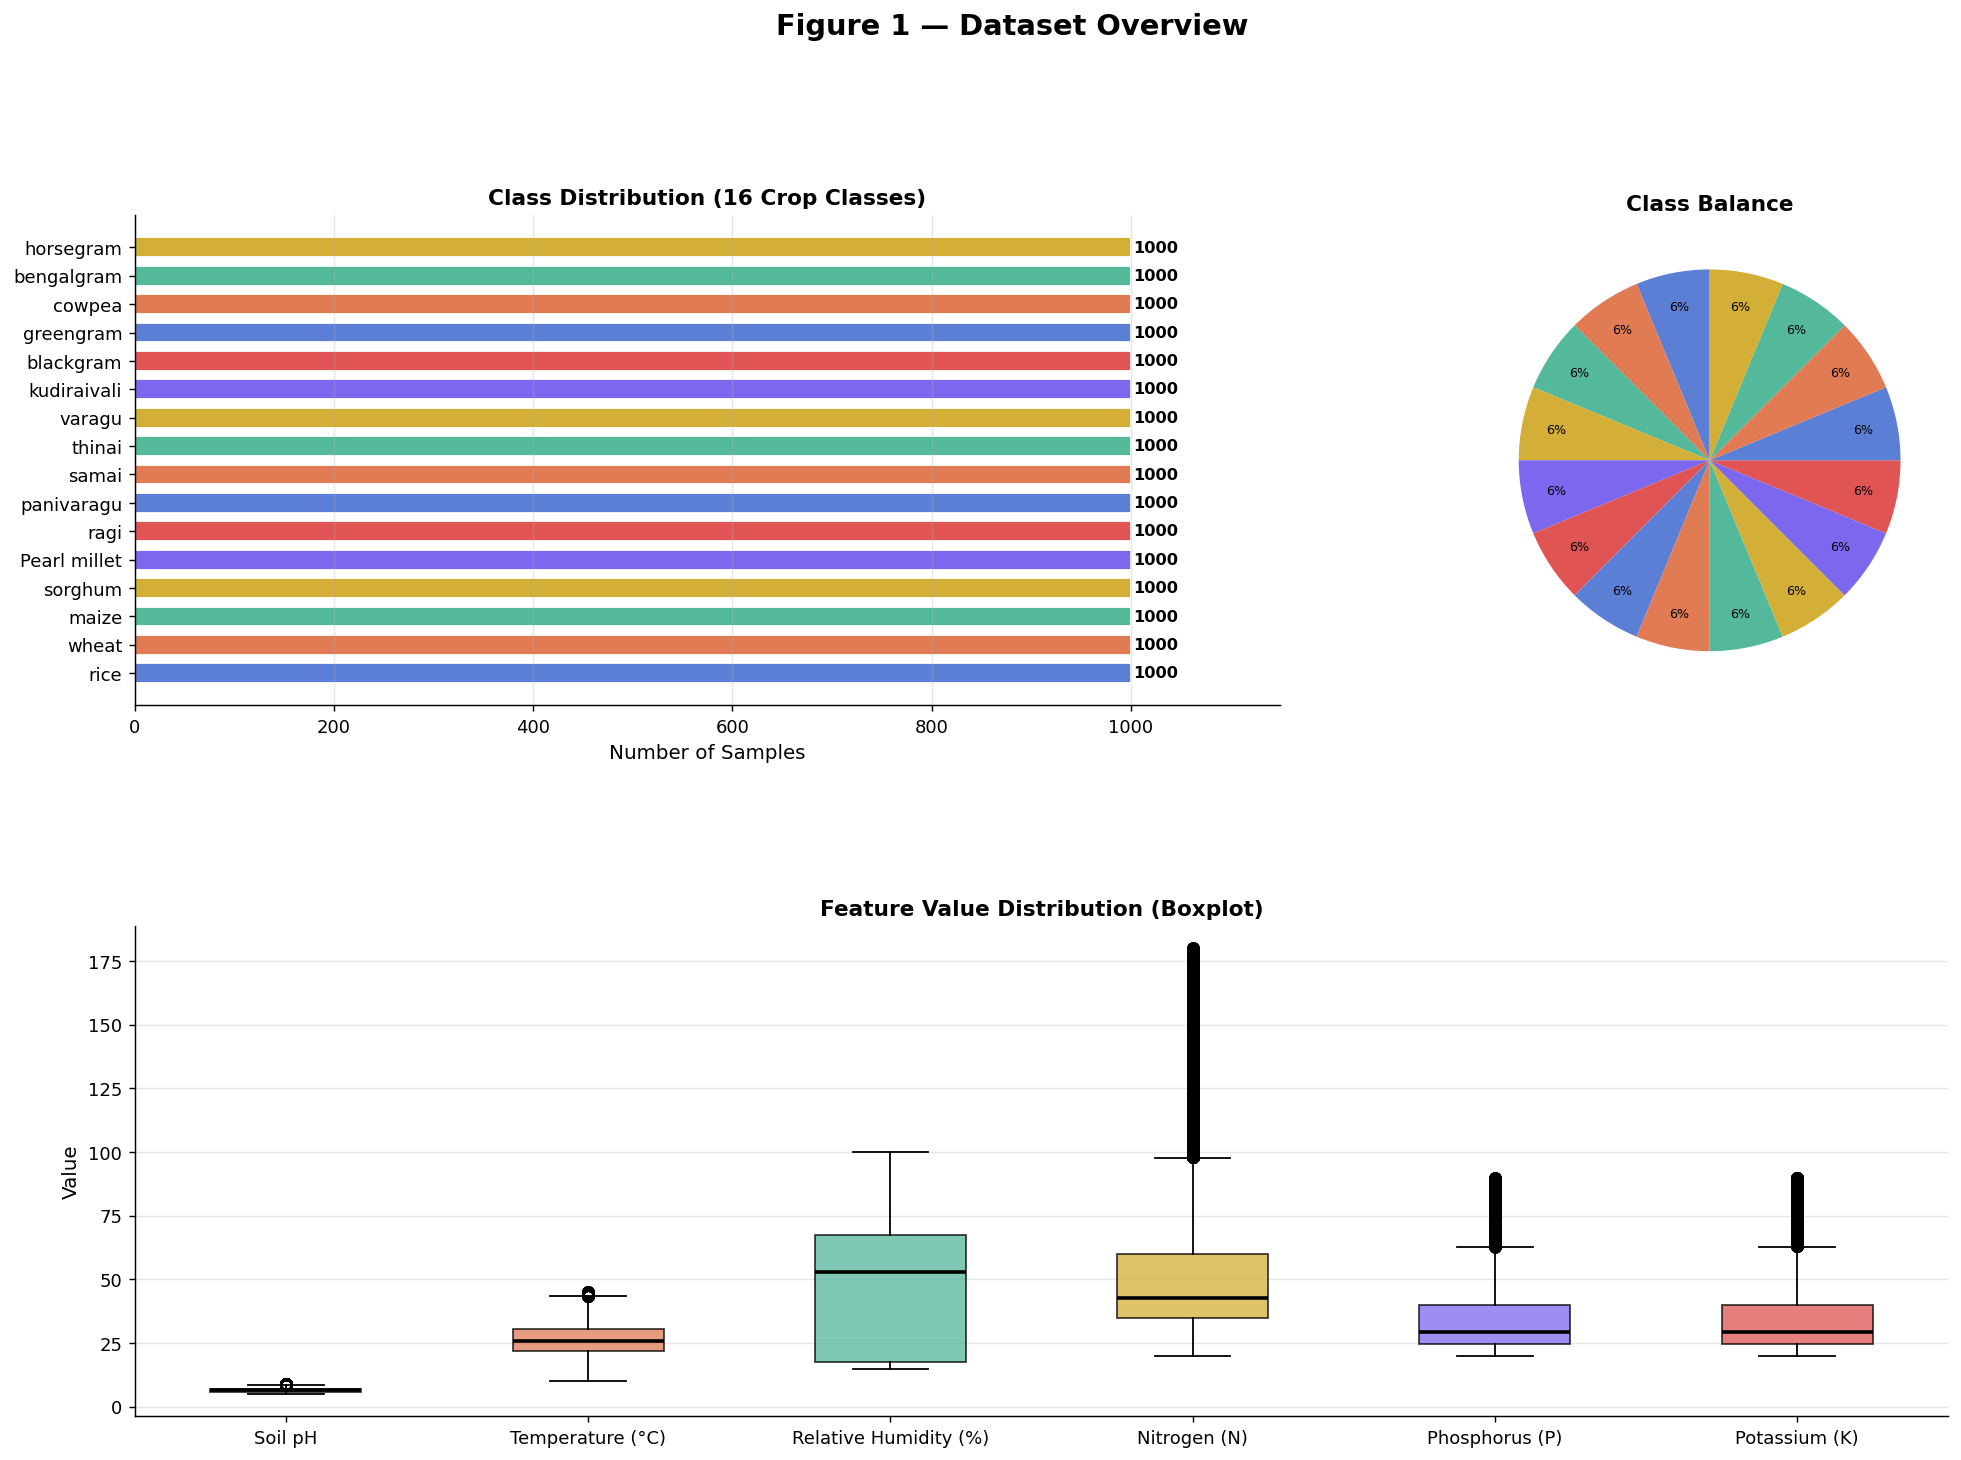

✅  Figure 1 saved.


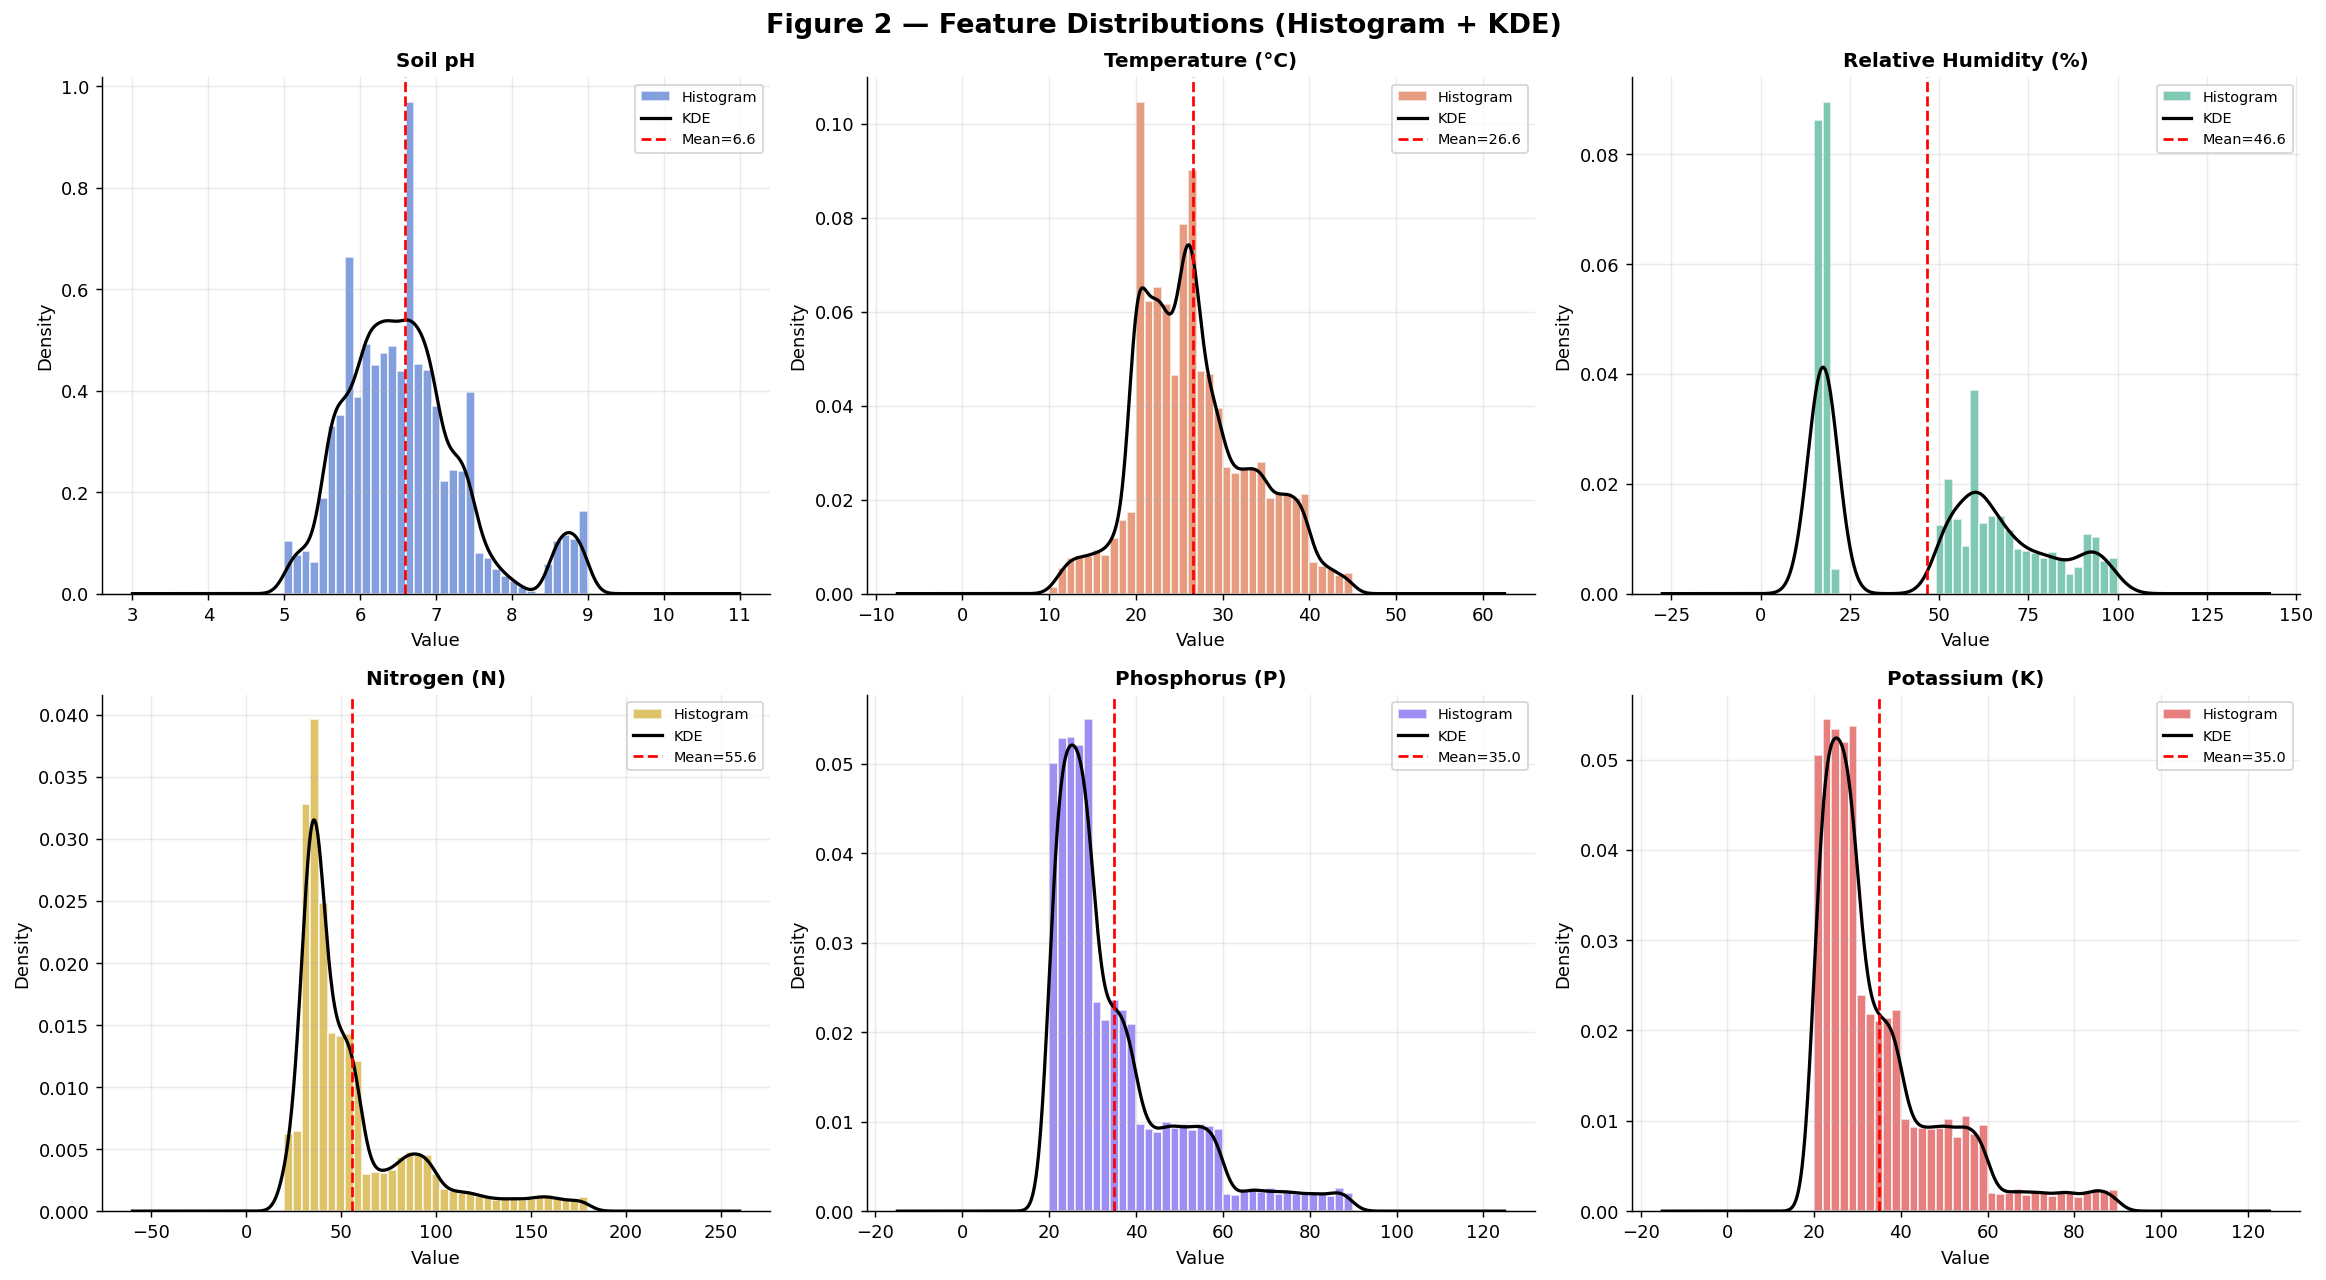

✅  Figure 2 saved.


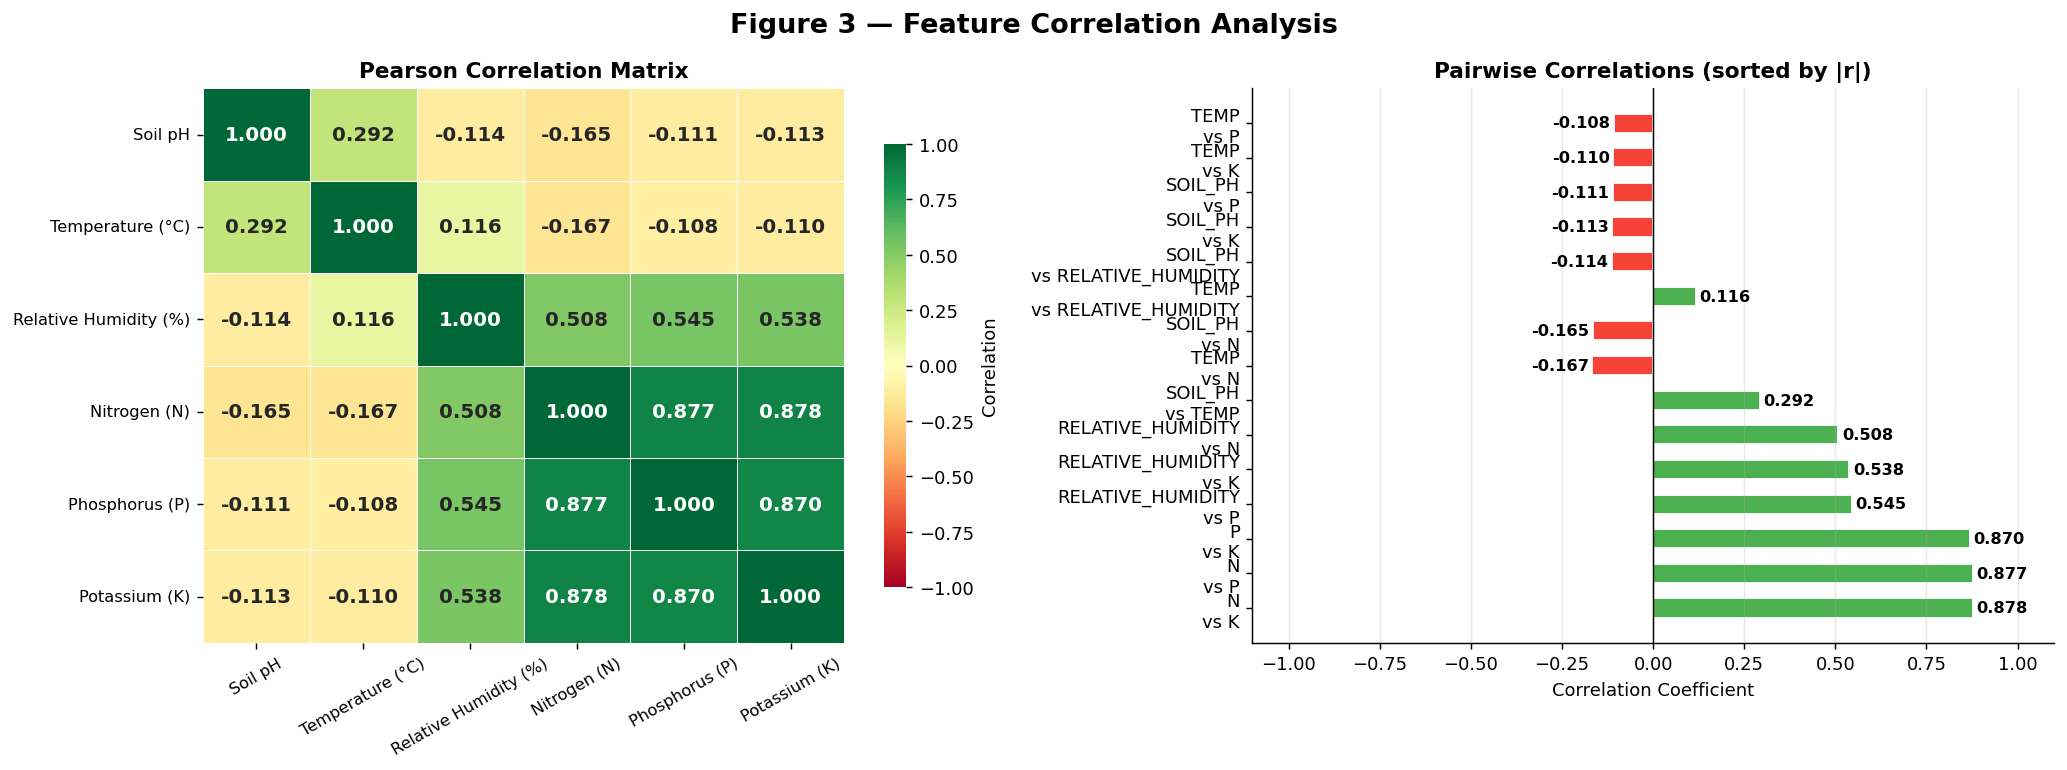

✅  Figure 3 saved.

✅  Train : 12,800  |  Test : 3,200
    Features scaled (StandardScaler) for LR, KNN, SVM

═════════════════════════════════════════════════════════════════
  TRAINING ALL MODELS
═════════════════════════════════════════════════════════════════

🔄  Random Forest … done (1.4s)
     Accuracy : 93.47%  |  Prec : 93.68%  |  Rec : 93.47%  |  F1 : 93.30%  |  AUC : 0.9948

🔄  Decision Tree … done (0.1s)
     Accuracy : 90.00%  |  Prec : 90.03%  |  Rec : 90.00%  |  F1 : 90.00%  |  AUC : 0.9467

🔄  Logistic Regression … done (2.4s)
     Accuracy : 82.72%  |  Prec : 82.38%  |  Rec : 82.72%  |  F1 : 82.28%  |  AUC : 0.9845

🔄  KNN … done (0.0s)
     Accuracy : 87.84%  |  Prec : 88.07%  |  Rec : 87.84%  |  F1 : 87.80%  |  AUC : 0.9786

🔄  SVM … done (5.2s)
     Accuracy : 89.53%  |  Prec : 90.22%  |  Rec : 89.53%  |  F1 : 89.29%  |  AUC : 0.9928

🏆  Best model : Random Forest  →  Accuracy 93.47%  |  AUC 0.9948


═════════════════════════════════════════════════════════════════
 

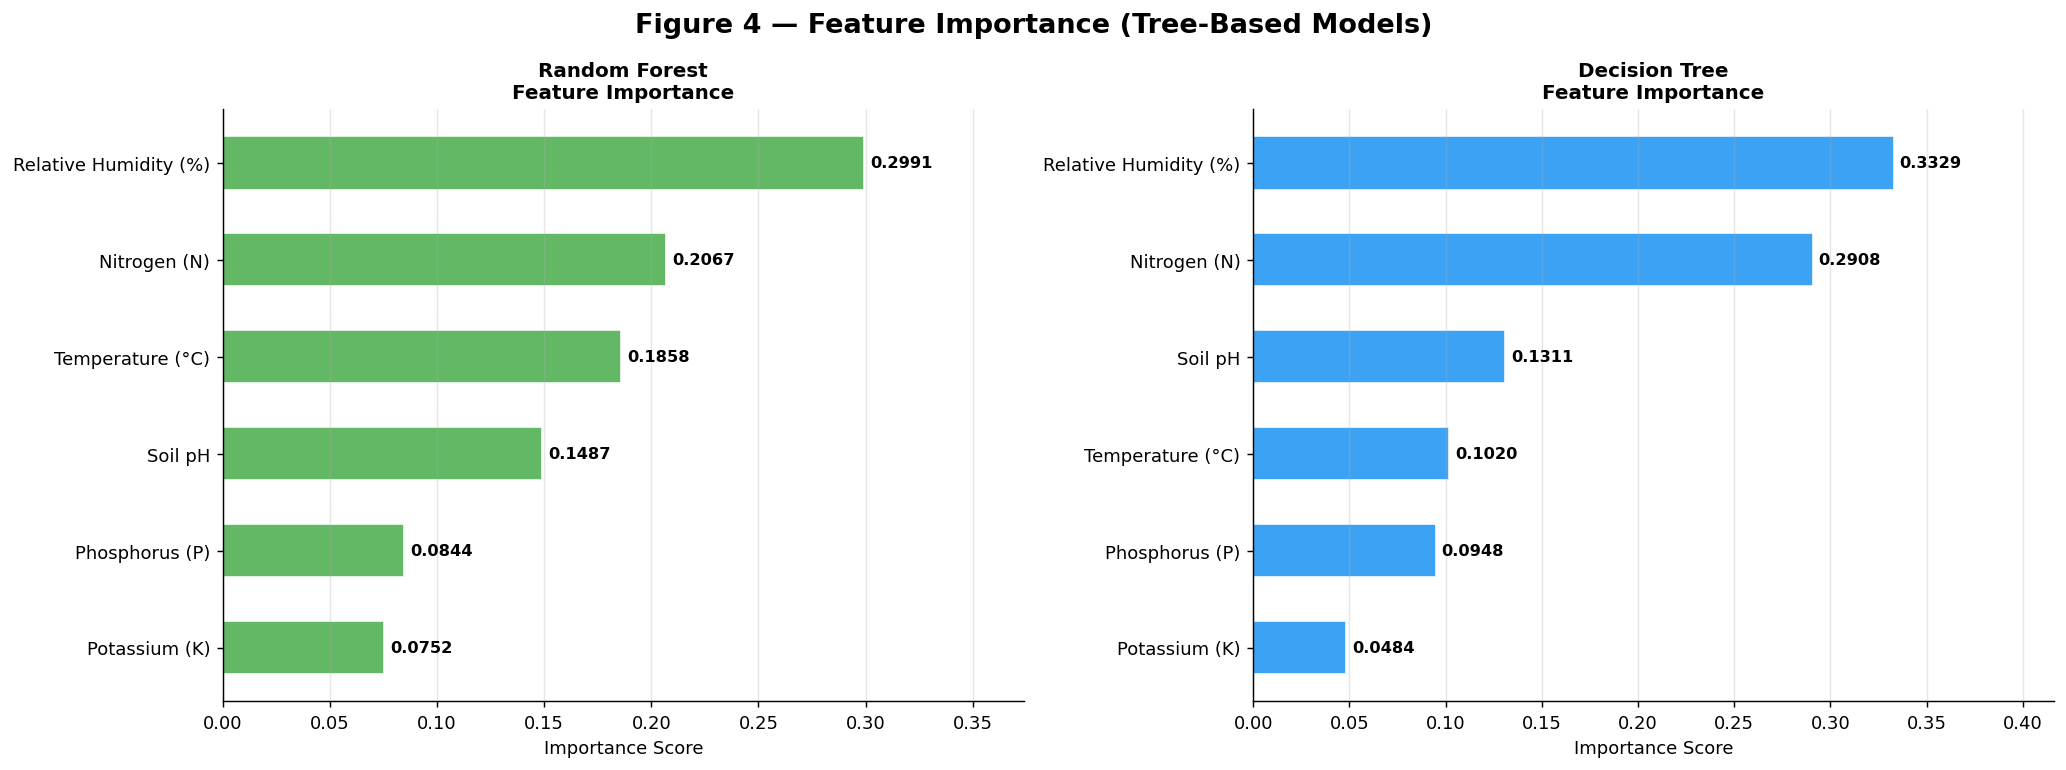

✅  Figure 4 saved.


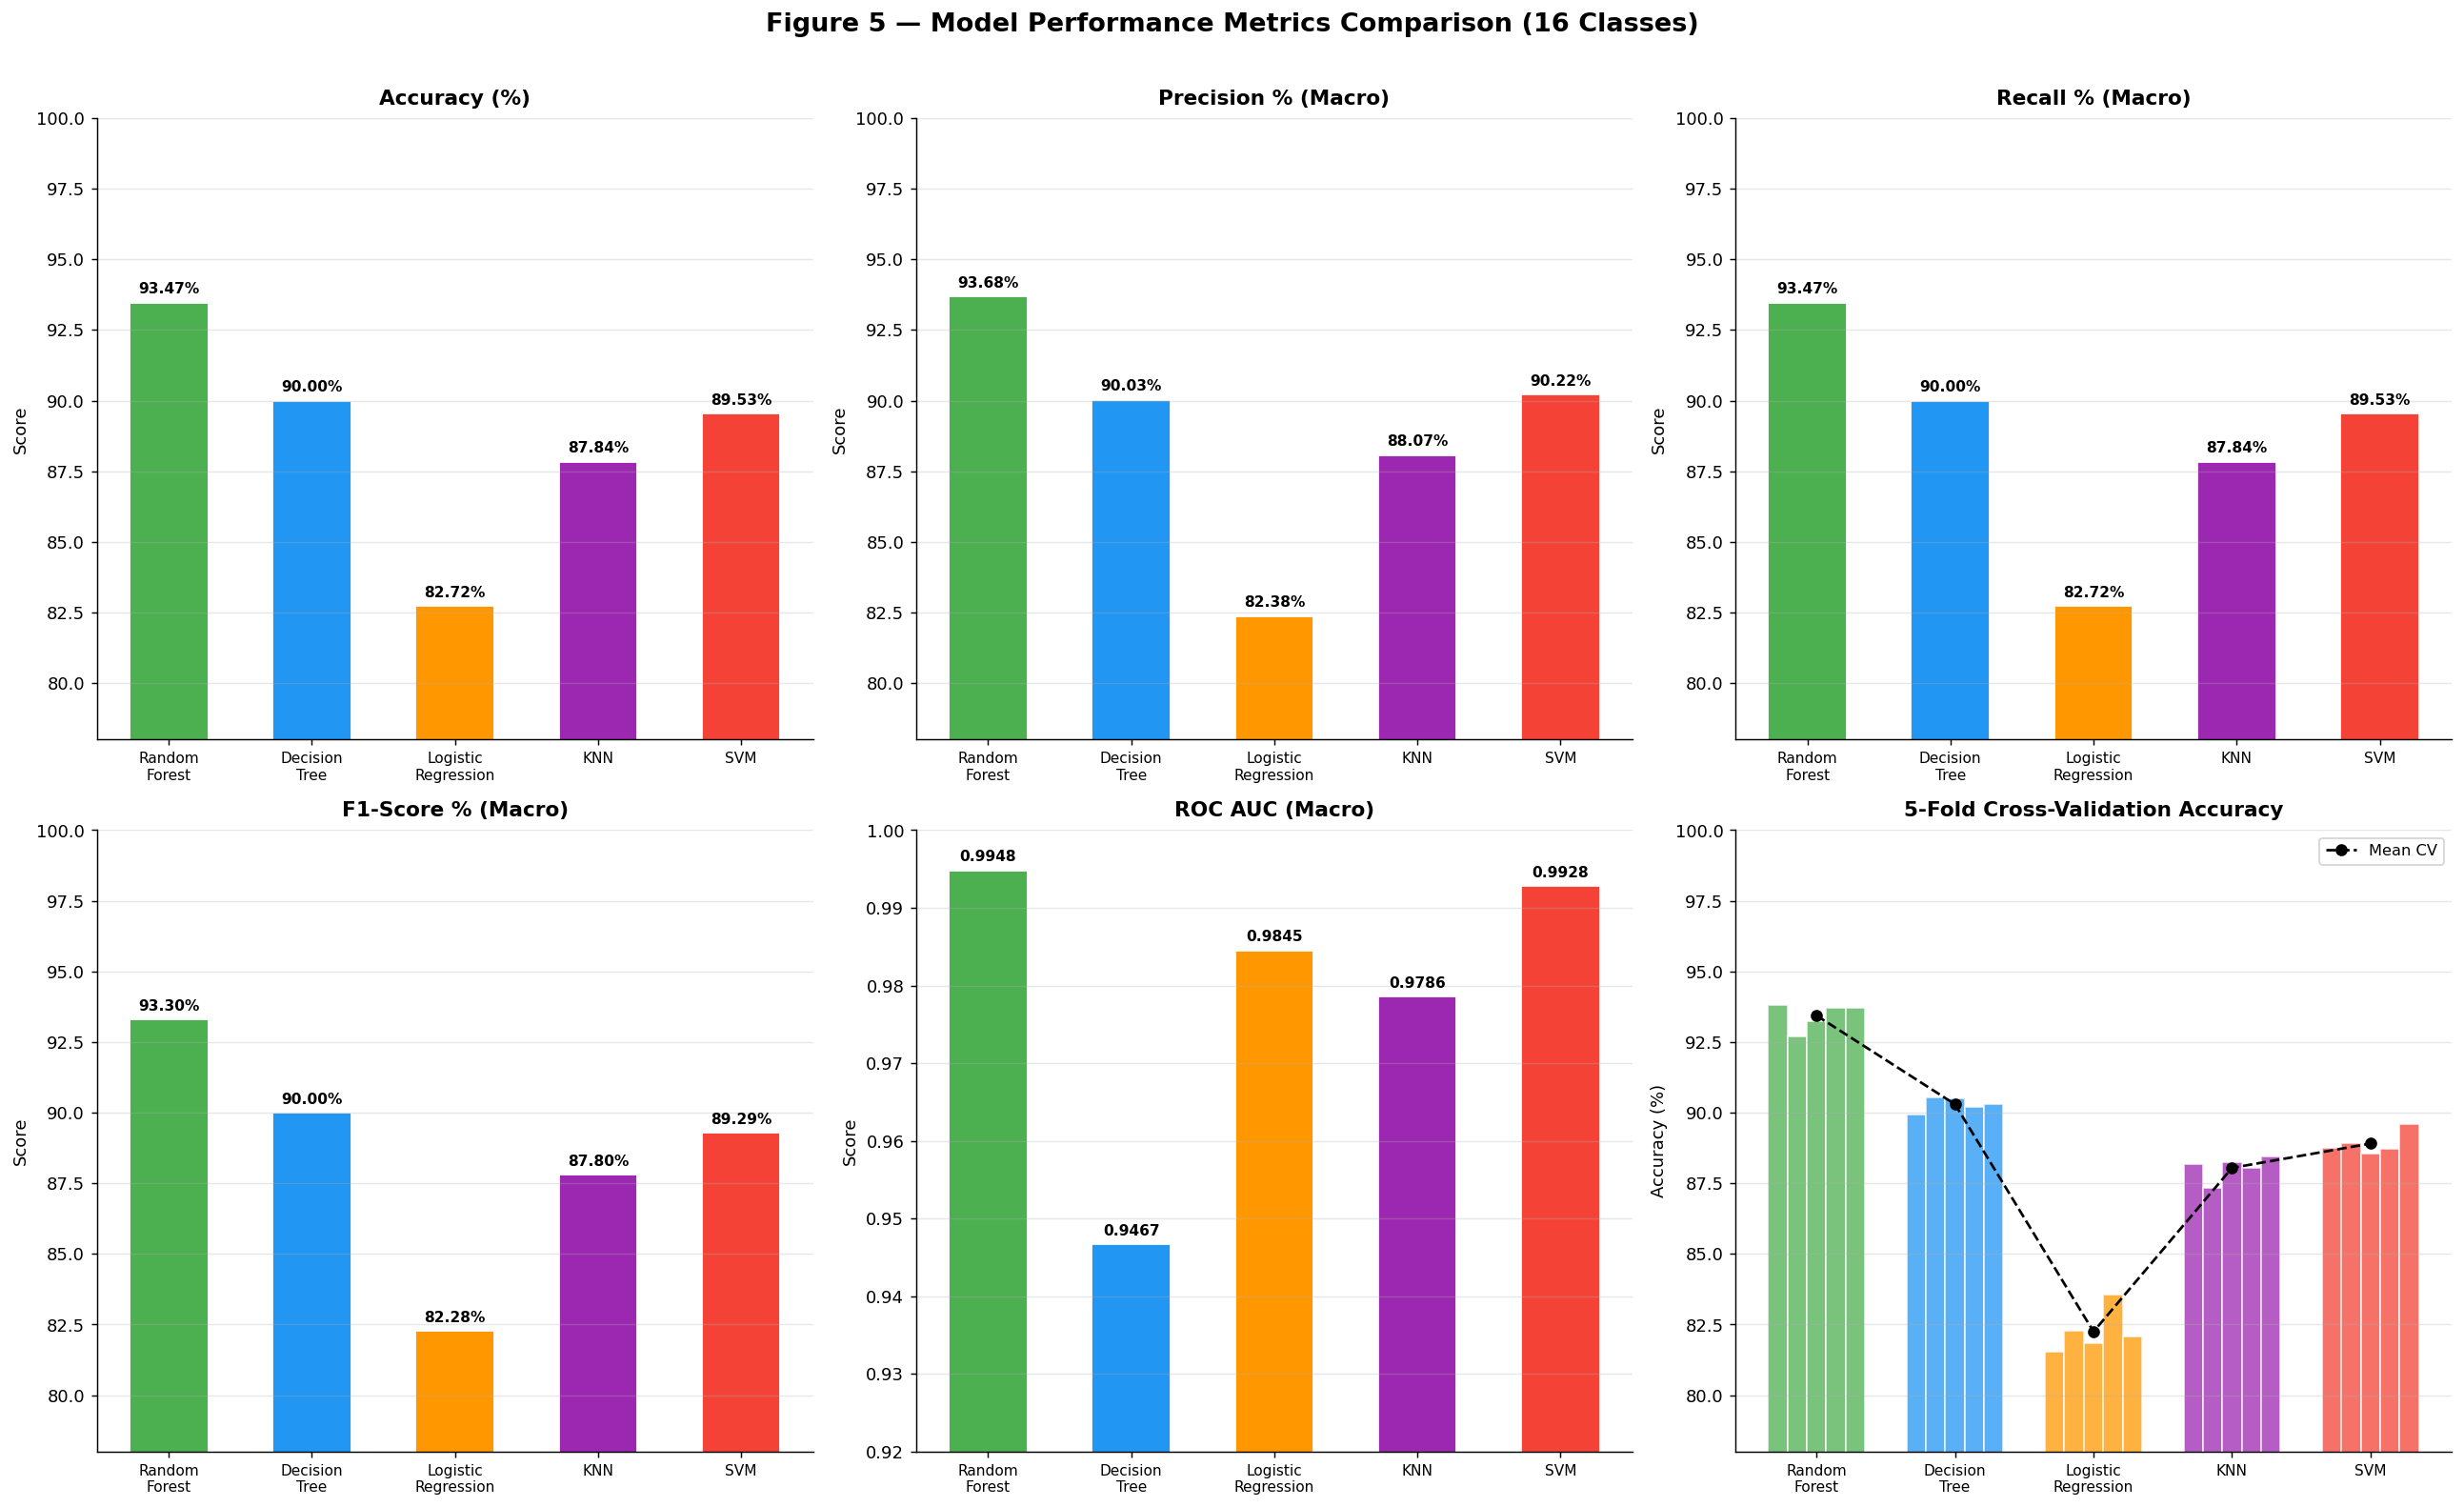

✅  Figure 5 saved.


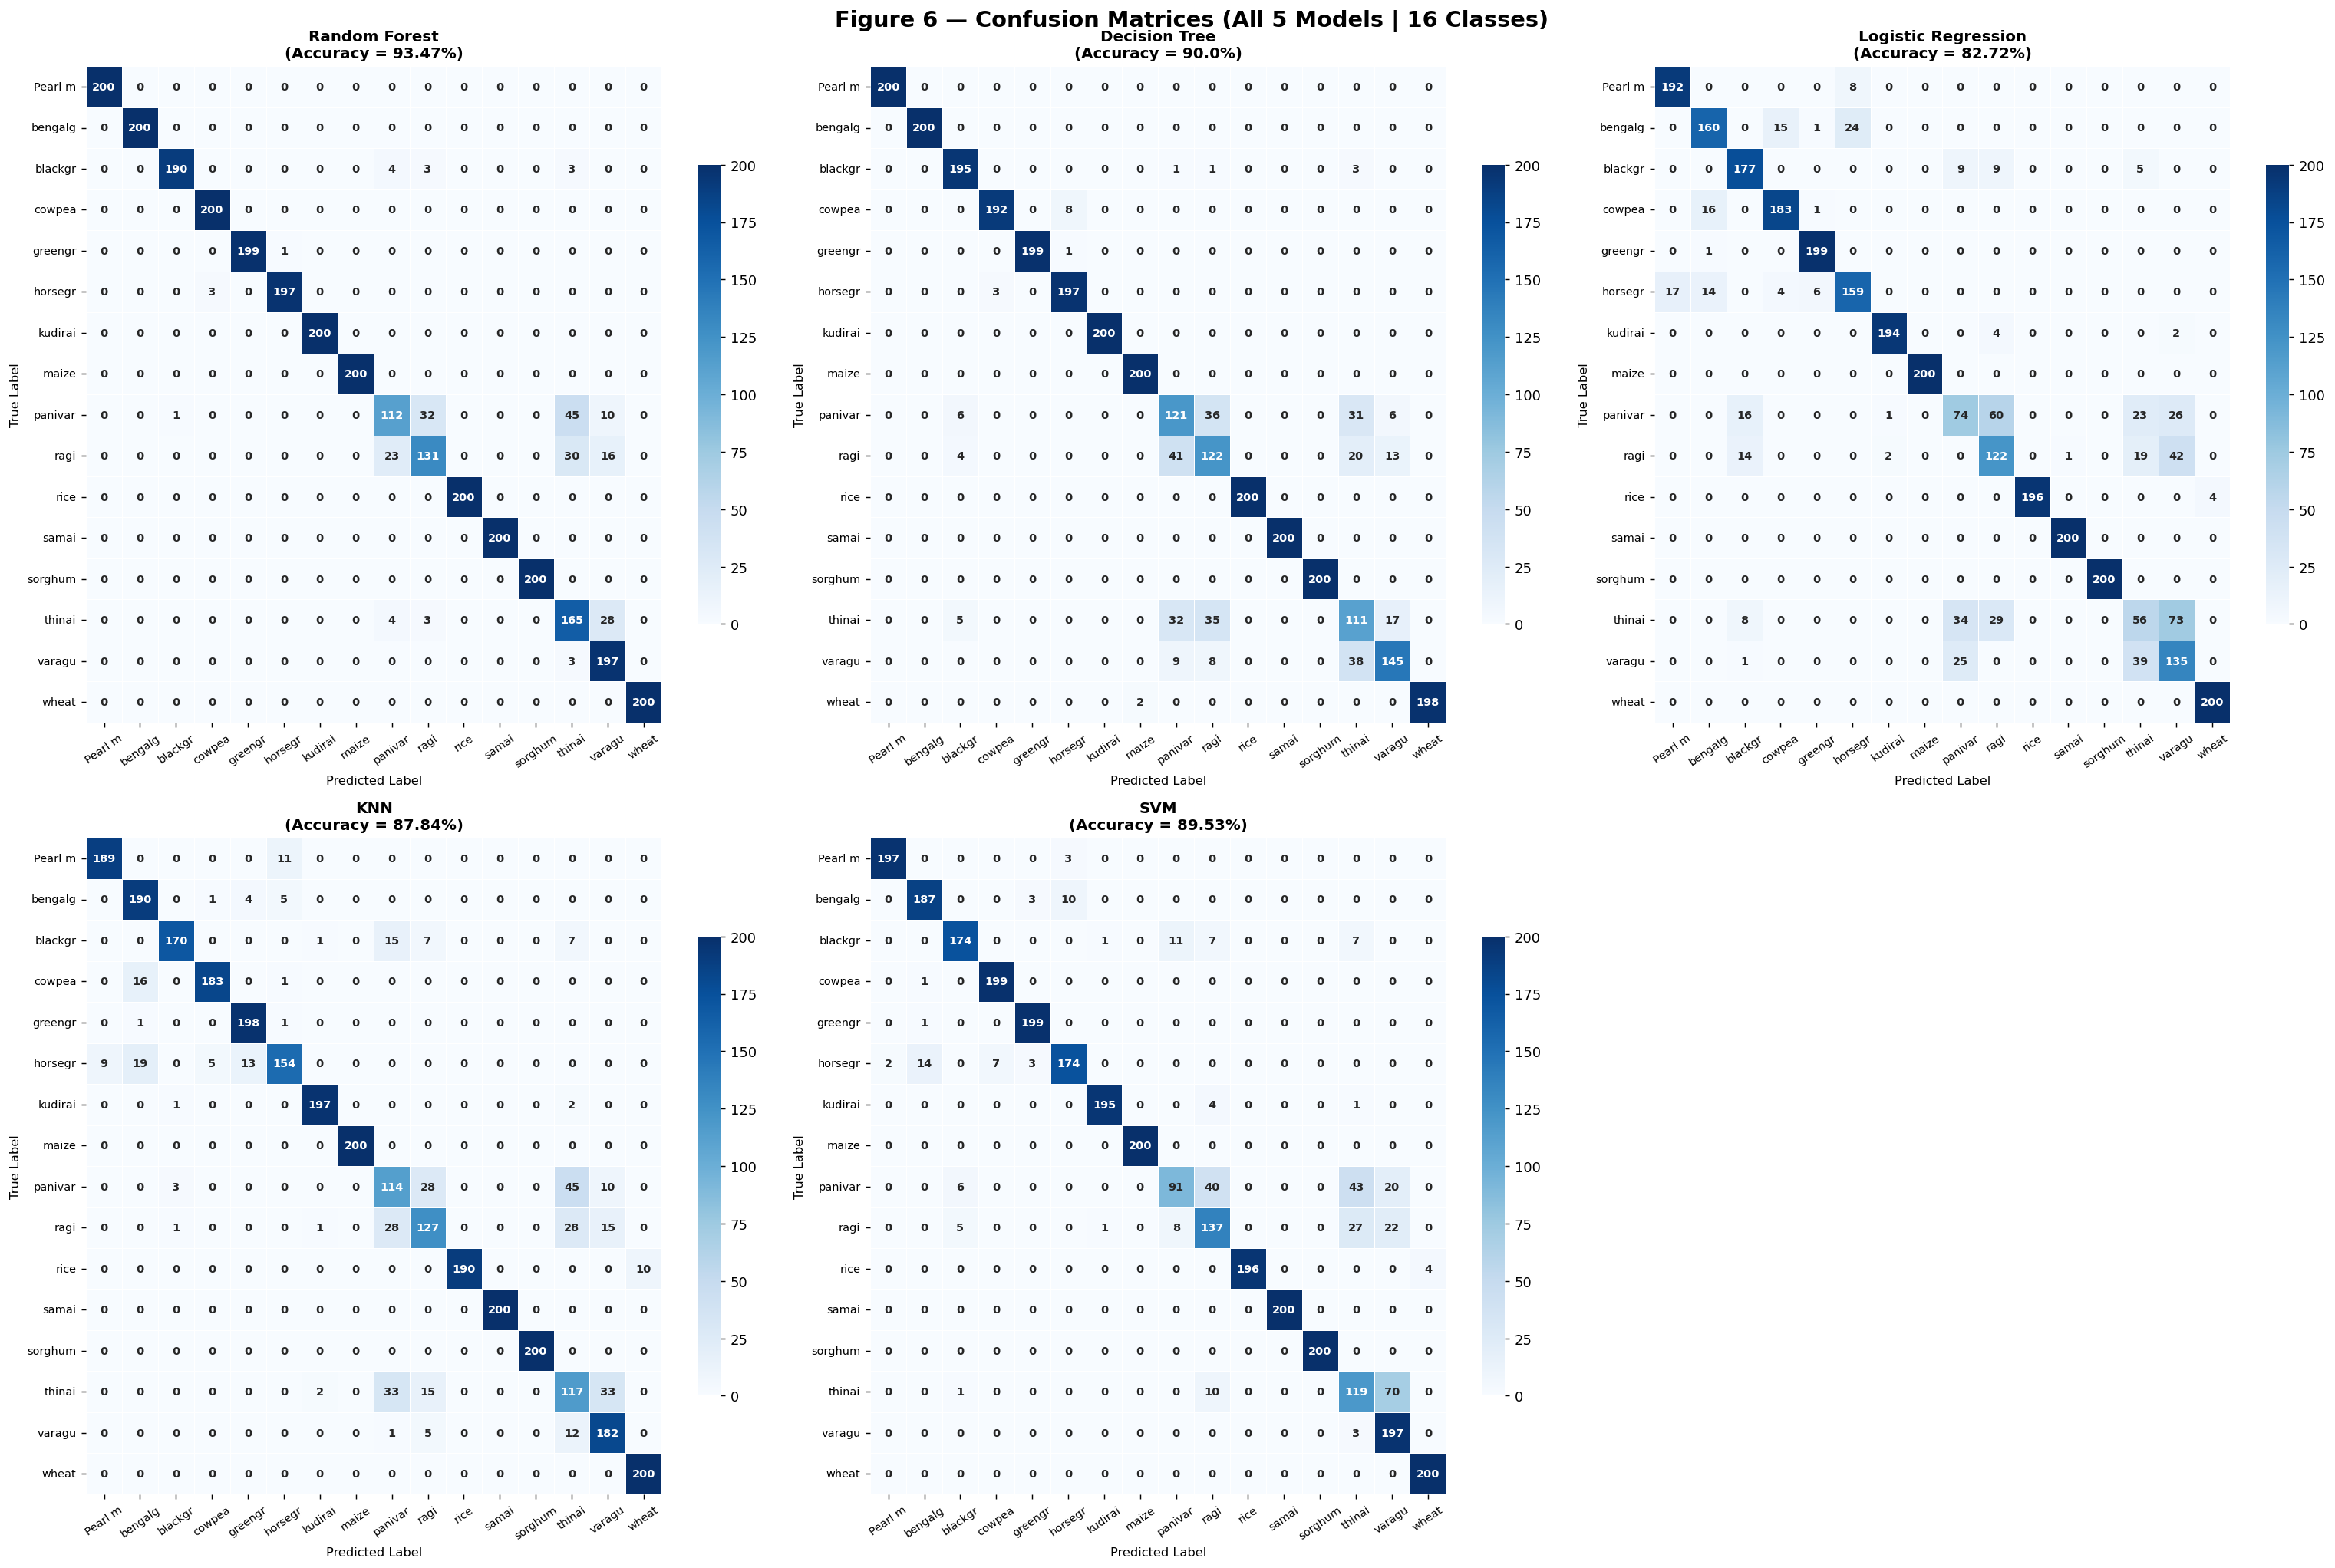

✅  Figure 6 saved.


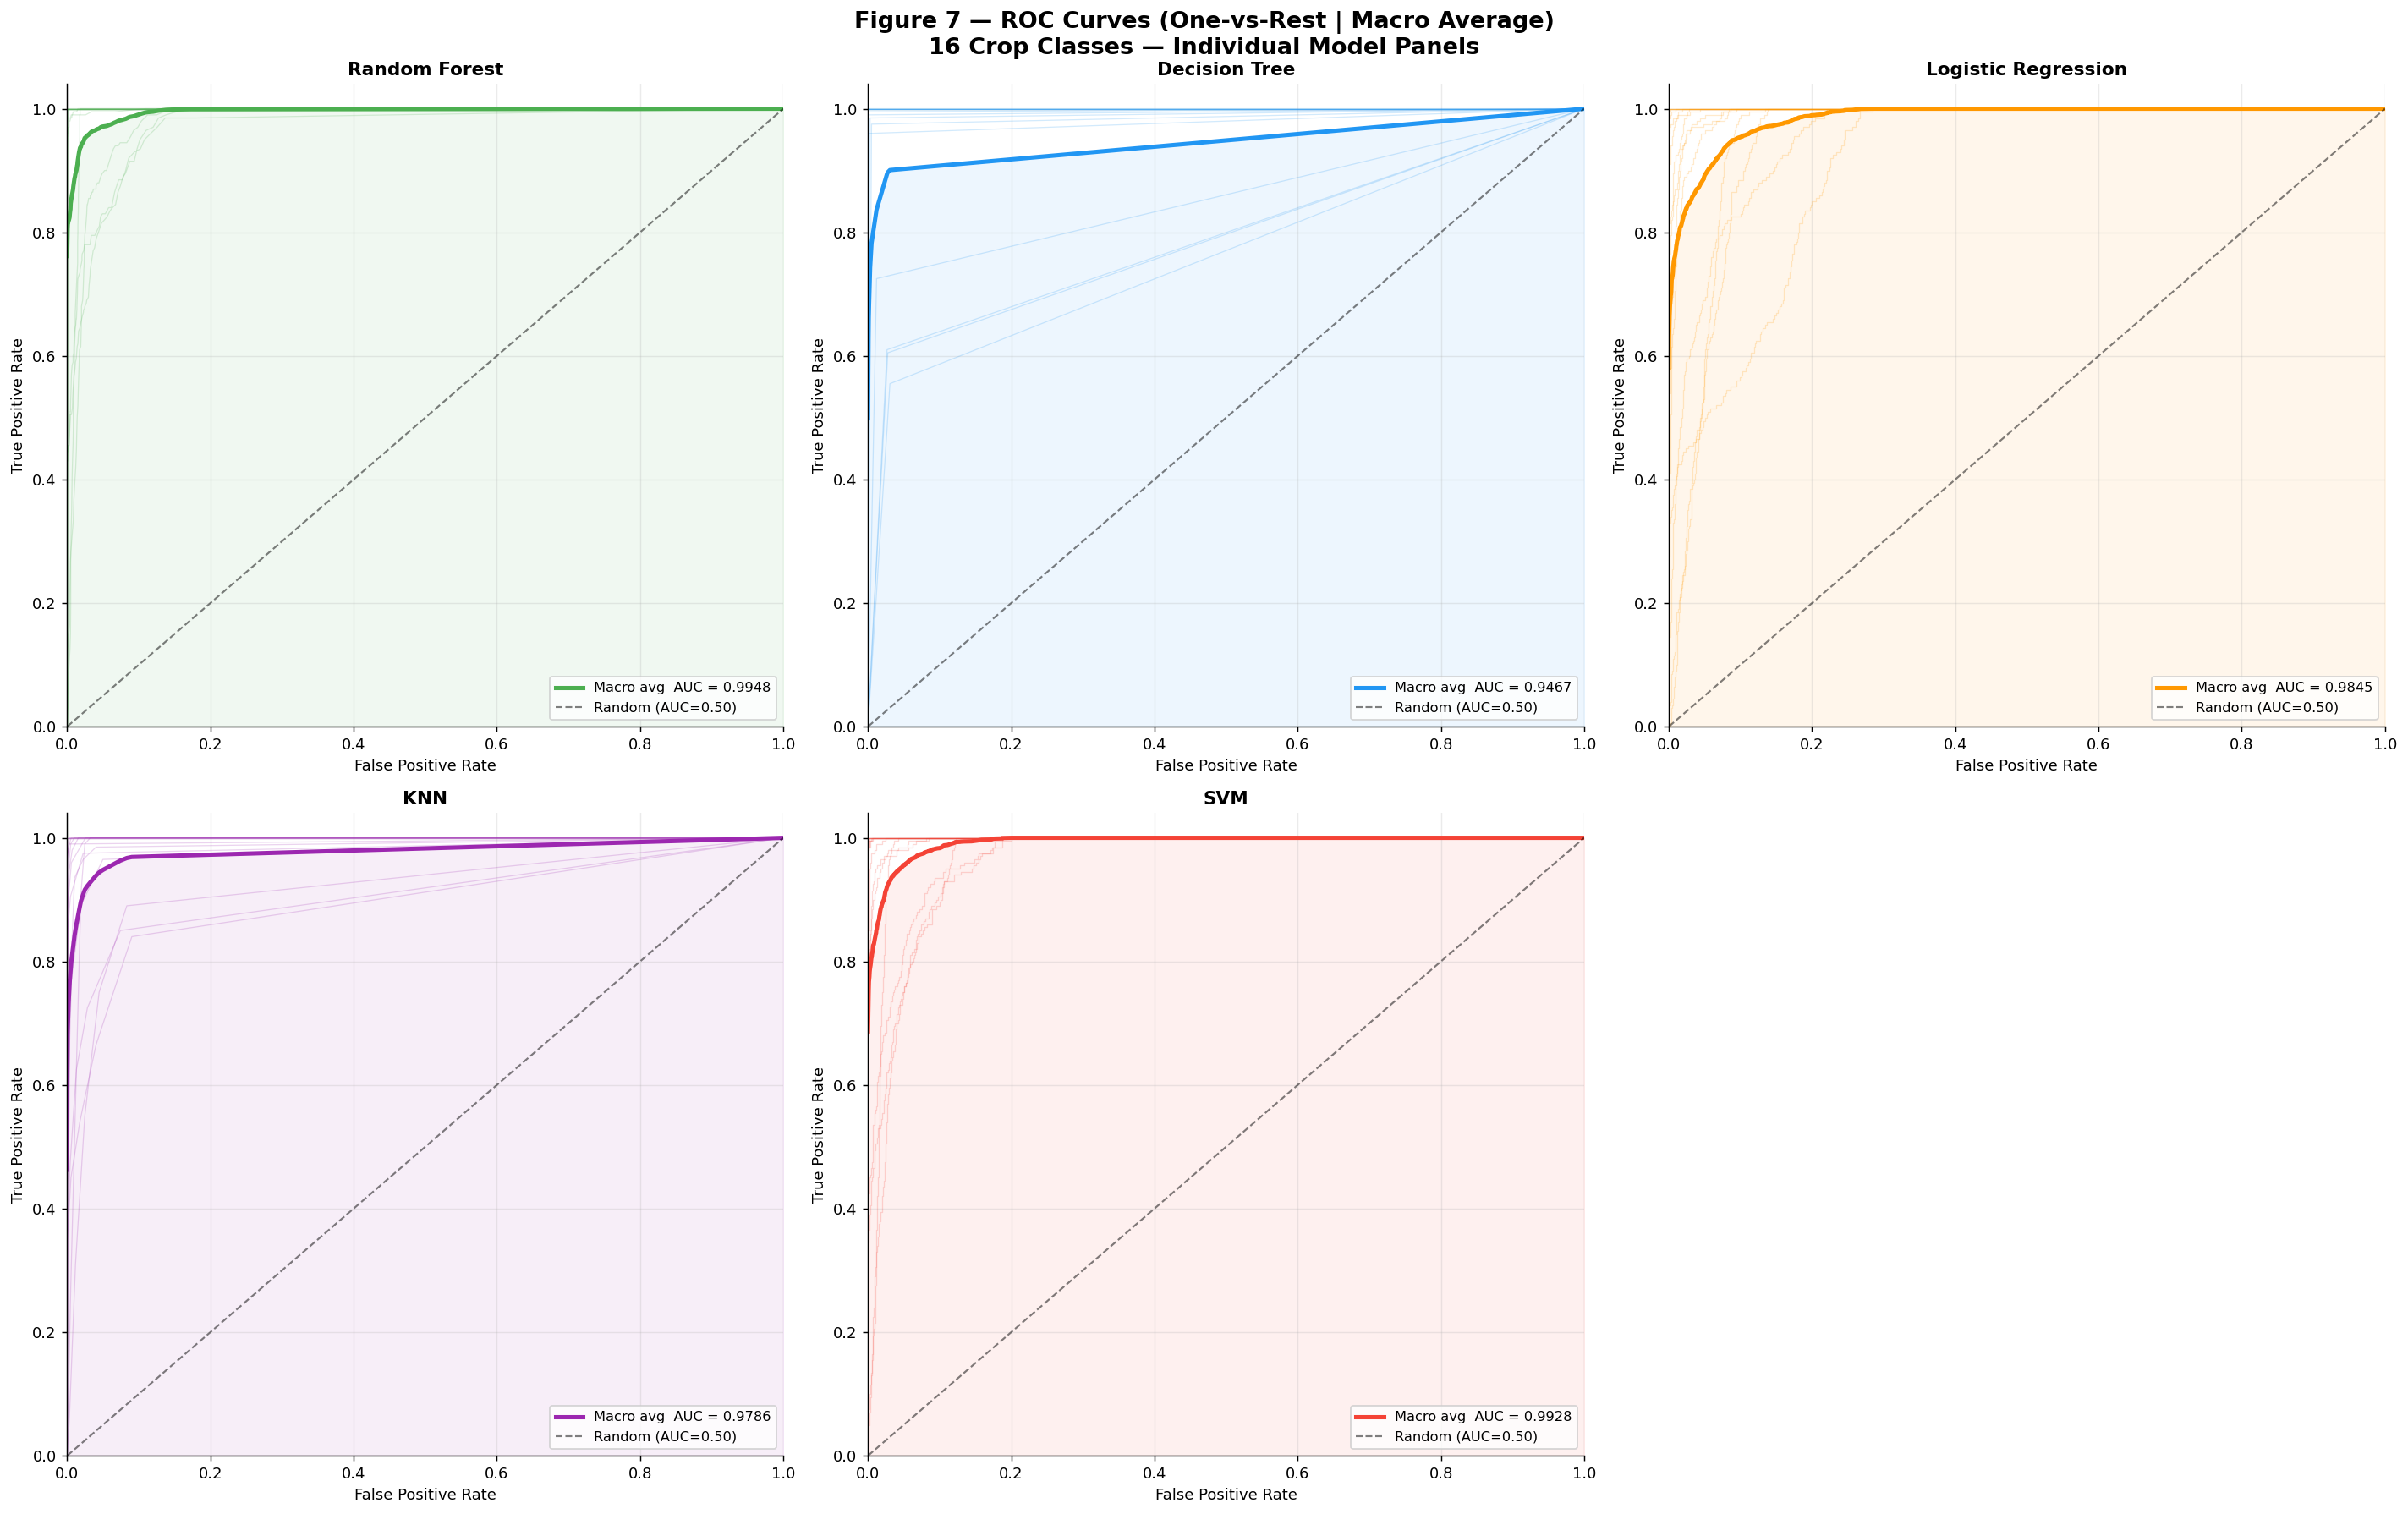

✅  Figure 7 saved.


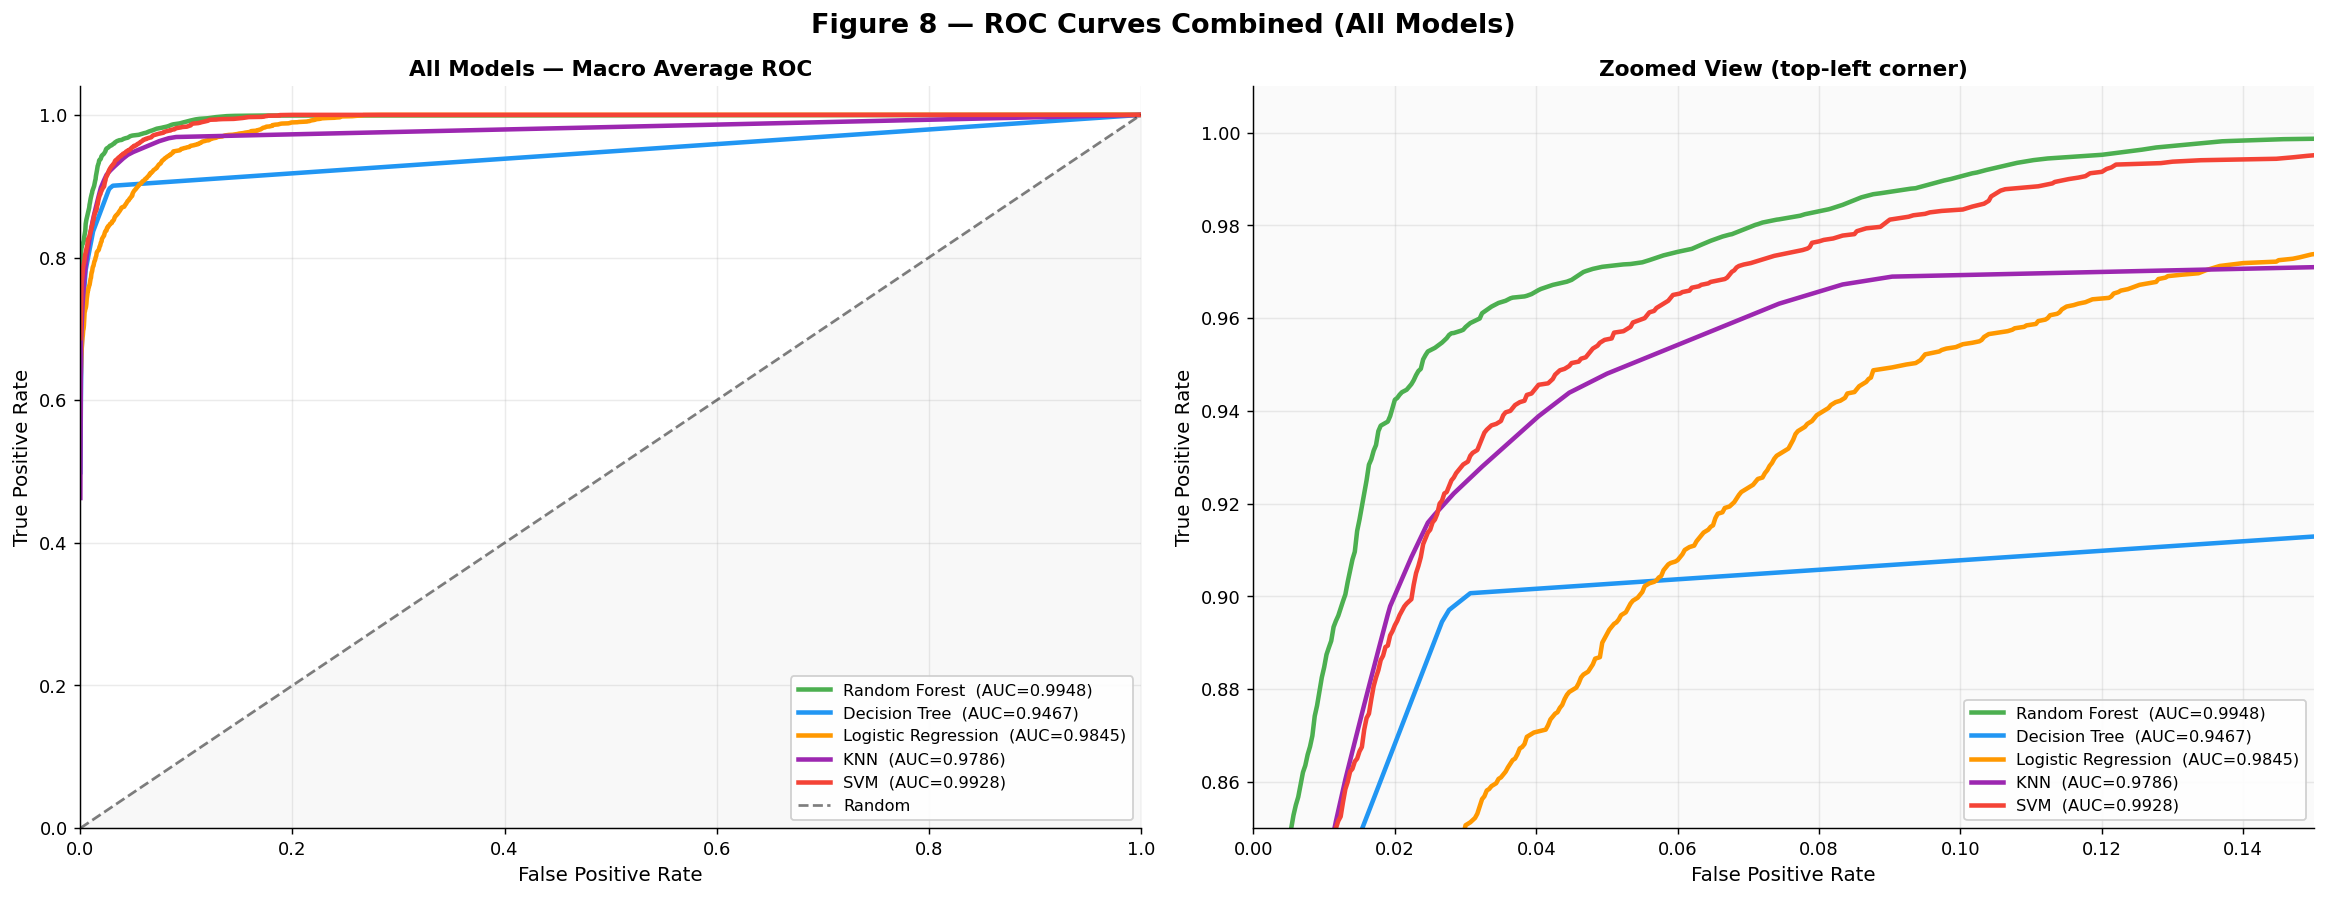

✅  Figure 8 saved.


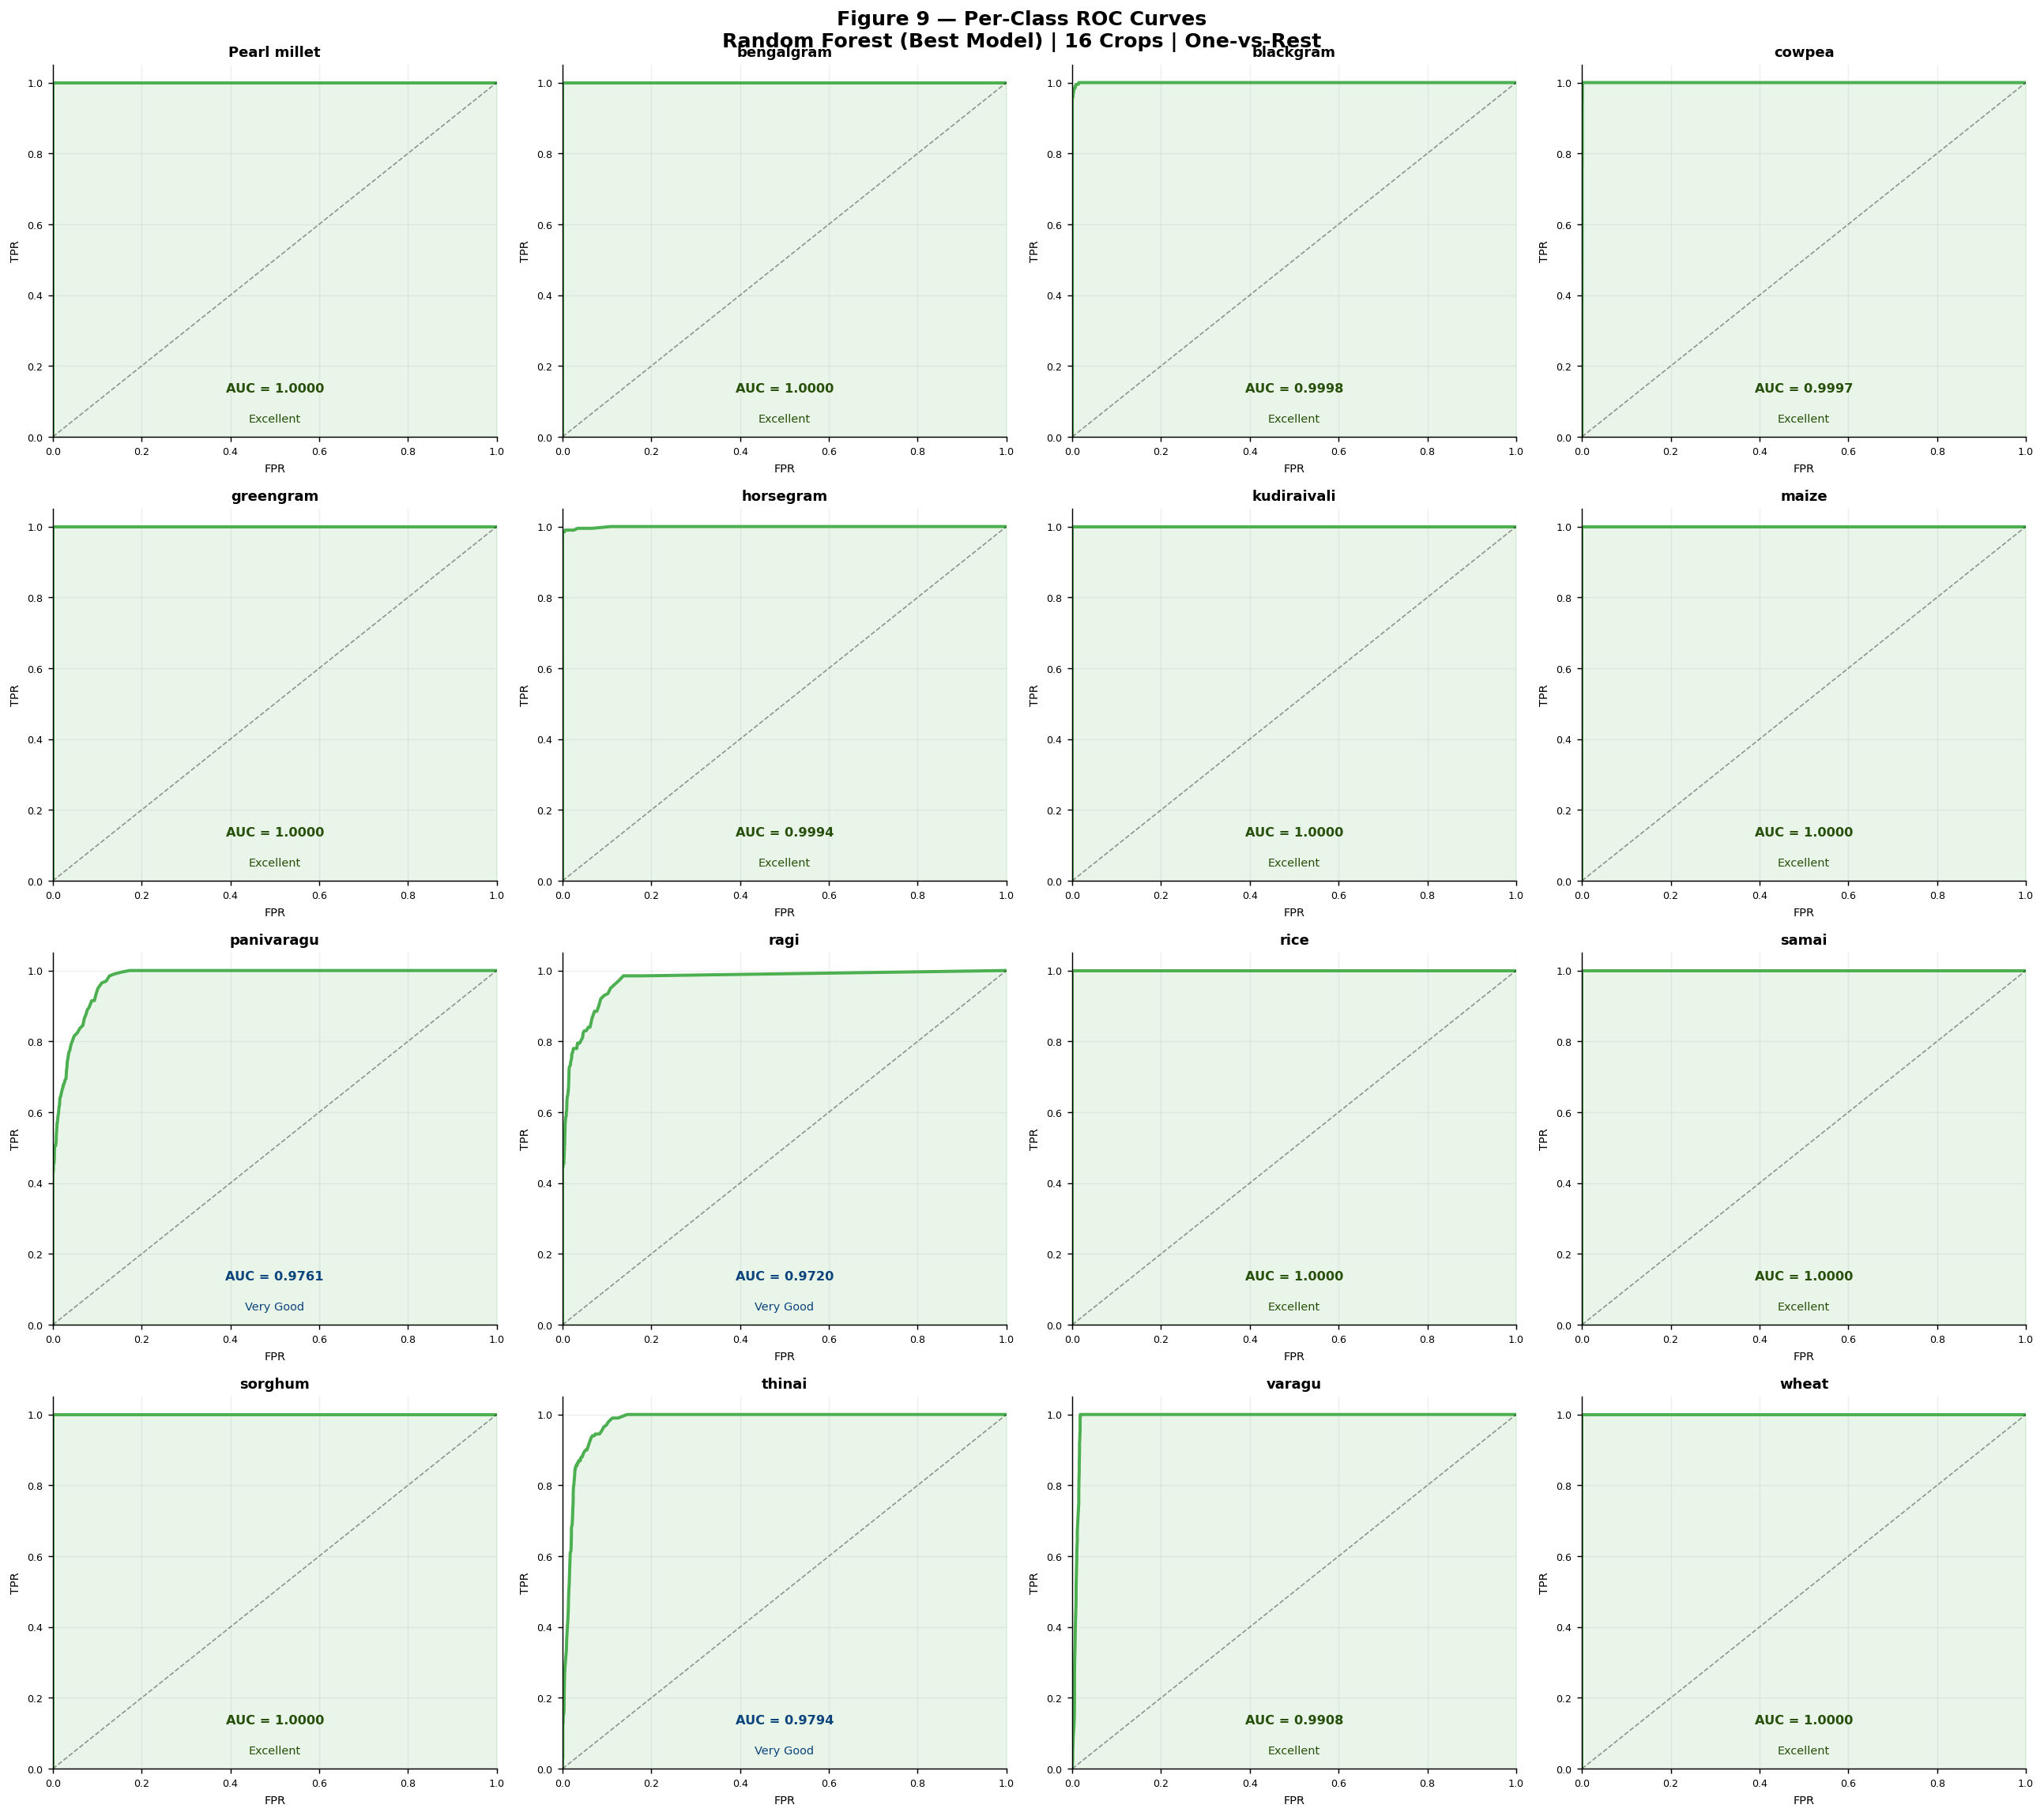

✅  Figure 9 saved  (best model = Random Forest).


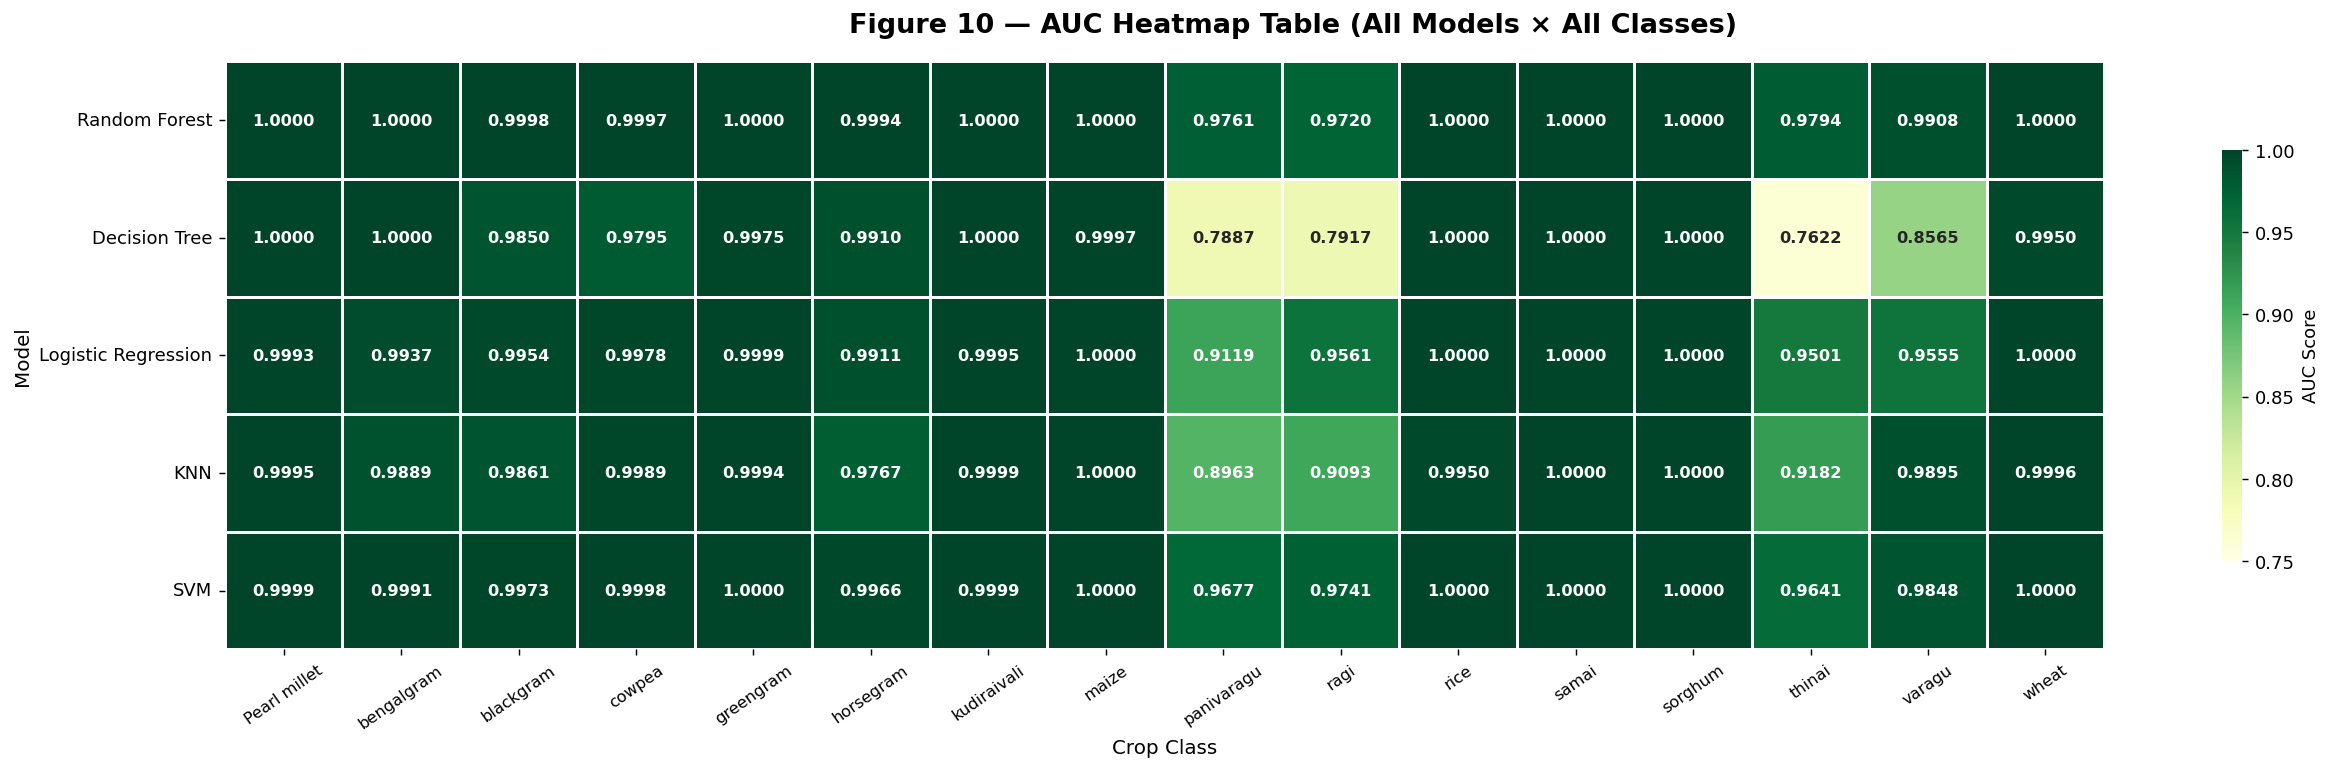

✅  Figure 10 saved.


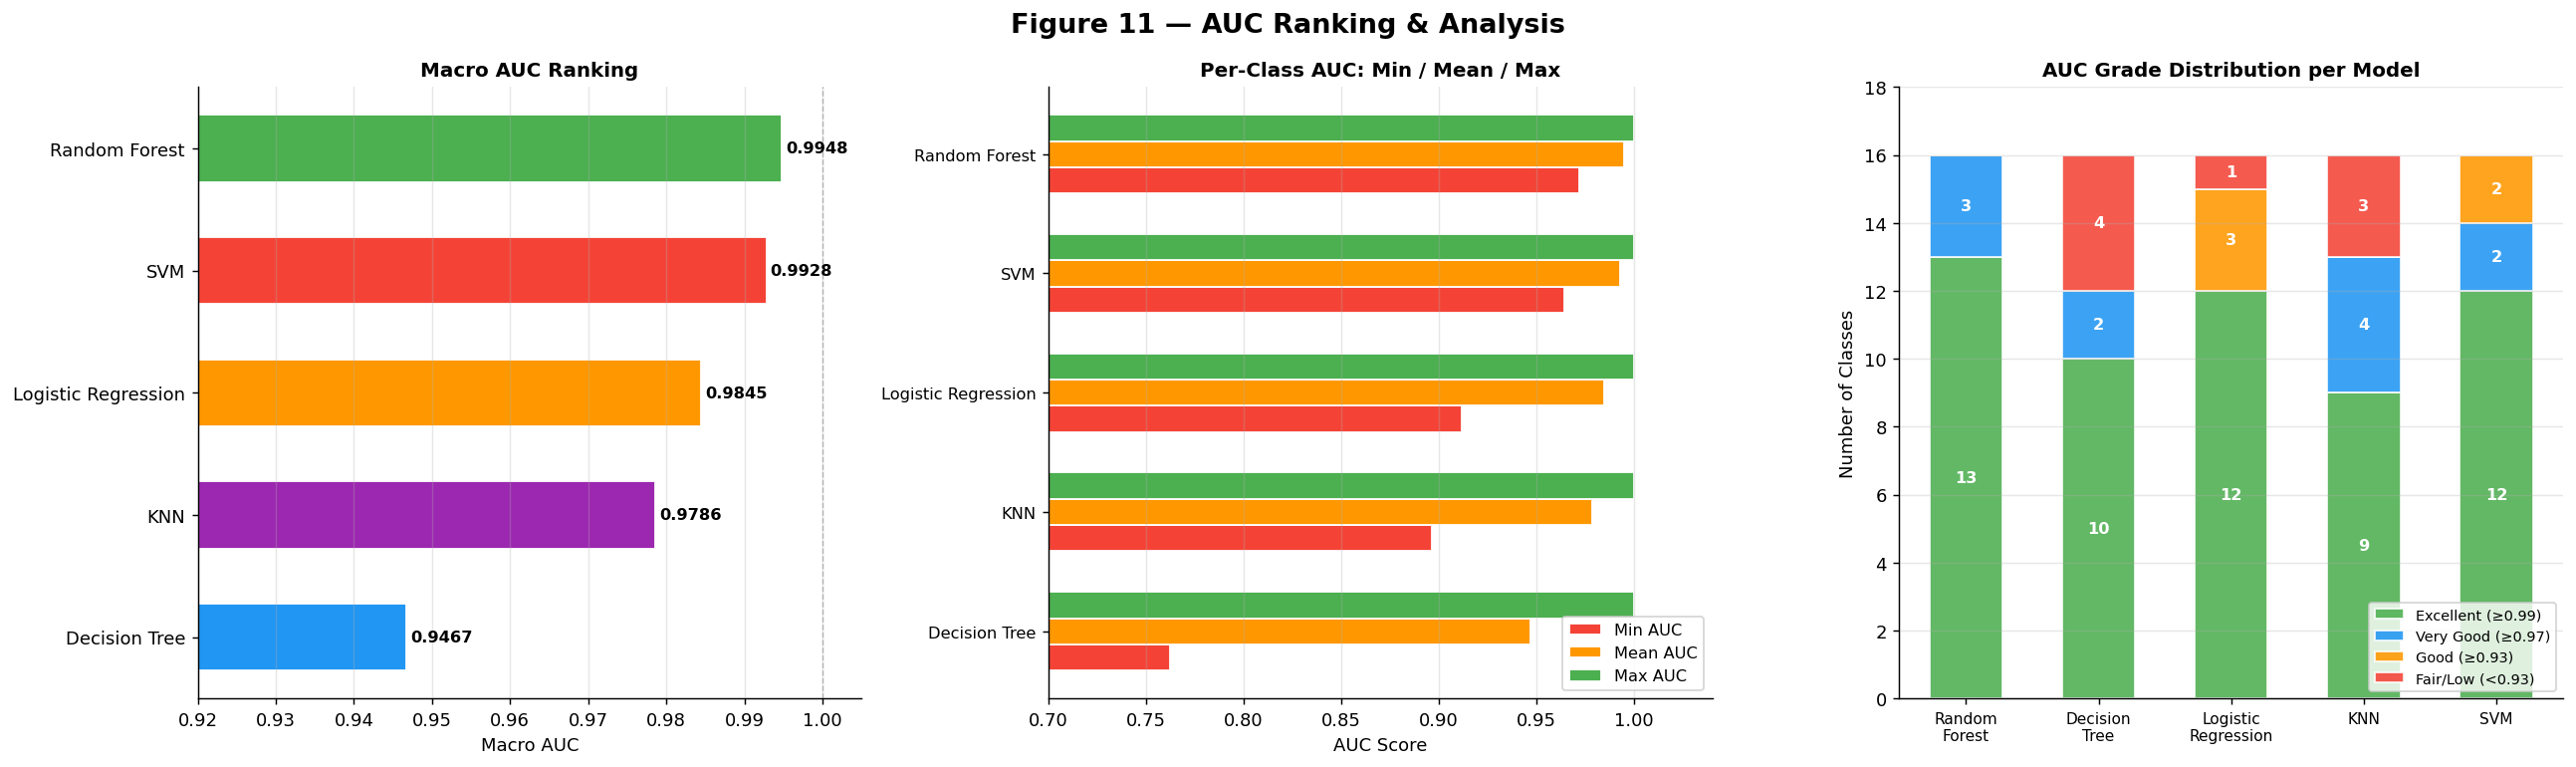

✅  Figure 11 saved.

✅  ALL_TABLES.xlsx saved  (T1 + T2 + T3×5 + T4 + T5 sheets)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



█████████████████████████████████████████████████████████████████
  COMPLETE PROJECT SUMMARY
█████████████████████████████████████████████████████████████████

── TABLE 1 : Overall Performance ──
                     Accuracy (%)  Precision % (Macro)  Recall % (Macro)  F1-Score % (Macro)  ROC AUC (Macro)
Random Forest             93.4700              93.6800           93.4700             93.3000           0.9948
Decision Tree             90.0000              90.0300           90.0000             90.0000           0.9467
Logistic Regression       82.7200              82.3800           82.7200             82.2800           0.9845
KNN                       87.8400              88.0700           87.8400             87.8000           0.9786
SVM                       89.5300              90.2200           89.5300             89.2900           0.9928

── TABLE 2 : Cross-Validation ──
                     Fold 1 (%)  Fold 2 (%)  Fold 3 (%)  Fold 4 (%)  Fold 5 (%)  Mean (%)  Std (%)
Model    

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   CROP RECOMMENDATION SYSTEM — COMPLETE ML PROJECT             ║
# ║   Dataset : Crop_recommendation_dataset.csv                     ║
# ║   Classes : 16 selected crops                                   ║
# ║   Features: SOIL_PH, TEMP, RELATIVE_HUMIDITY, N, P, K          ║
# ║                                                                  ║
# ║   SECTIONS:                                                      ║
# ║   1.  Libraries & Upload                                         ║
# ║   2.  Dataset Overview & EDA                                     ║
# ║   3.  Feature Analysis (Distribution, Correlation, Importance)   ║
# ║   4.  Preprocessing                                              ║
# ║   5.  Model Training (RF, DT, LR, KNN, SVM)                    ║
# ║   6.  Table 1  — Overall Performance Metrics                    ║
# ║   7.  Table 2  — Cross-Validation Scores                        ║
# ║   8.  Table 3  — Per-Class AUC (each model)                    ║
# ║   9.  Table 4  — Combined AUC Matrix                            ║
# ║   10. Table 5  — AUC Ranking Summary                            ║
# ║   11. Figure 1 — Dataset Overview Charts                        ║
# ║   12. Figure 2 — Feature Distributions                          ║
# ║   13. Figure 3 — Feature Correlation Heatmap                    ║
# ║   14. Figure 4 — Feature Importance (RF & DT)                   ║
# ║   15. Figure 5 — Metrics Comparison Bar Charts                  ║
# ║   16. Figure 6 — Confusion Matrices (all 5 models)              ║
# ║   17. Figure 7 — ROC Curves Individual (per model)              ║
# ║   18. Figure 8 — ROC Curves Combined (all models)               ║
# ║   19. Figure 9 — Per-Class ROC 4×4 Grid (best model)           ║
# ║   20. Figure 10 — AUC Heatmap Table                             ║
# ║   21. Figure 11 — AUC Ranking Chart                             ║
# ║   22. Save All Tables (CSV + Excel) & Download                  ║
# ╚══════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────
# SECTION 1 — LIBRARIES & UPLOAD
# ─────────────────────────────────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, time, io
warnings.filterwarnings("ignore")

from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing      import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics            import (accuracy_score, precision_score, recall_score,
                                         f1_score, classification_report,
                                         confusion_matrix, roc_curve, auc)
from sklearn.ensemble           import RandomForestClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.svm                import SVC

plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 10,
})

COLORS = {
    'Random Forest'      : '#4CAF50',
    'Decision Tree'      : '#2196F3',
    'Logistic Regression': '#FF9800',
    'KNN'                : '#9C27B0',
    'SVM'                : '#F44336',
}
PALETTE  = list(COLORS.values())
FEAT_COL = ['#5B7FD4','#E07B54','#54B89B','#D4AF37','#7B68EE','#E05454']

from google.colab import files
print("📂  Upload  Crop_recommendation_dataset.csv")
uploaded = files.upload()
fname    = list(uploaded.keys())[0]
df_full  = pd.read_csv(io.BytesIO(uploaded[fname]))
print(f"\n✅  Loaded  →  {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# ─────────────────────────────────────────────────────────────────
# SECTION 2 — DATASET OVERVIEW & EDA
# ─────────────────────────────────────────────────────────────────
SELECTED = [
    'rice','wheat','maize','sorghum','Pearl millet',
    'ragi','panivaragu','samai','thinai','varagu',
    'kudiraivali','blackgram','greengram','cowpea',
    'bengalgram','horsegram'
]
FEATURES = ['SOIL_PH','TEMP','RELATIVE_HUMIDITY','N','P','K']
FEAT_LABELS = {
    'SOIL_PH'          : 'Soil pH',
    'TEMP'             : 'Temperature (°C)',
    'RELATIVE_HUMIDITY': 'Relative Humidity (%)',
    'N'                : 'Nitrogen (N)',
    'P'                : 'Phosphorus (P)',
    'K'                : 'Potassium (K)',
}

df = df_full[df_full['CROPS'].isin(SELECTED)].copy().reset_index(drop=True)
le = LabelEncoder()
df['CROP_ENC'] = le.fit_transform(df['CROPS'])
class_names = le.classes_
n_classes   = len(class_names)

print("\n" + "═"*65)
print("  DATASET OVERVIEW")
print("═"*65)
print(f"  Total rows       : {df.shape[0]:,}")
print(f"  Features         : {FEATURES}")
print(f"  Target           : CROPS  ({n_classes} classes)")
print(f"  Missing values   : {df[FEATURES].isnull().sum().sum()}")
print(f"  Samples/class    : {df['CROPS'].value_counts().iloc[0]} (perfectly balanced)")
print("\n  Statistical Summary:")
print(df[FEATURES].describe().round(3).to_string())

# ─────────────────────────────────────────────────────────────────
# SECTION 3 — FEATURE ANALYSIS
# ─────────────────────────────────────────────────────────────────

# ── Figure 1 : Dataset Overview ─────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Figure 1 — Dataset Overview', fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# 1a — Class distribution bar
ax1 = fig.add_subplot(gs[0, :2])
counts = df['CROPS'].value_counts().sort_values(ascending=True)
bars   = ax1.barh(counts.index, counts.values,
                  color=[FEAT_COL[i % 6] for i in range(len(counts))],
                  edgecolor='white', height=0.7)
ax1.set_xlabel('Number of Samples', fontsize=11)
ax1.set_title('Class Distribution (16 Crop Classes)', fontsize=12, fontweight='bold')
for bar, v in zip(bars, counts.values):
    ax1.text(v + 2, bar.get_y()+bar.get_height()/2, str(v),
             va='center', fontsize=9, fontweight='bold')
ax1.set_xlim(0, 1150)
ax1.grid(axis='x', alpha=0.3)

# 1b — Pie chart
ax2 = fig.add_subplot(gs[0, 2])
wedge_cols = [FEAT_COL[i % 6] for i in range(n_classes)]
ax2.pie(counts.values, labels=None, colors=wedge_cols,
        autopct='%1.0f%%', pctdistance=0.82,
        textprops={'fontsize': 7}, startangle=90)
ax2.set_title('Class Balance', fontsize=12, fontweight='bold')

# 1c — Feature boxplot
ax3 = fig.add_subplot(gs[1, :])
feat_data = [df[f].values for f in FEATURES]
bp = ax3.boxplot(feat_data, patch_artist=True, notch=False,
                 medianprops={'color':'black','linewidth':2})
for patch, col in zip(bp['boxes'], FEAT_COL):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax3.set_xticklabels([FEAT_LABELS[f] for f in FEATURES], fontsize=10)
ax3.set_title('Feature Value Distribution (Boxplot)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Value', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 1 saved.")

# ── Figure 2 : Feature Distributions ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 2 — Feature Distributions (Histogram + KDE)',
             fontsize=15, fontweight='bold')
for ax, feat, col in zip(axes.flatten(), FEATURES, FEAT_COL):
    ax.hist(df[feat], bins=35, color=col, edgecolor='white', alpha=0.75,
            density=True, label='Histogram')
    df[feat].plot.kde(ax=ax, color='black', lw=1.8, label='KDE')
    ax.set_title(FEAT_LABELS[feat], fontsize=11, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='red', lw=1.5, linestyle='--',
               label=f'Mean={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 2 saved.")

# ── Figure 3 : Correlation Heatmap ──────────────────────────────
corr = df[FEATURES].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 3 — Feature Correlation Analysis',
             fontsize=15, fontweight='bold')

# Heatmap
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            annot_kws={'size':11, 'weight':'bold'},
            xticklabels=[FEAT_LABELS[f] for f in FEATURES],
            yticklabels=[FEAT_LABELS[f] for f in FEATURES],
            ax=axes[0], cbar_kws={'label':'Correlation', 'shrink':0.8})
axes[0].set_title('Pearson Correlation Matrix', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

# Bar chart of top correlations
pairs, vals = [], []
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        pairs.append(f"{FEATURES[i]}\nvs {FEATURES[j]}")
        vals.append(corr.iloc[i,j])
sorted_pairs = sorted(zip(vals, pairs), key=lambda x: abs(x[0]), reverse=True)
sv, sp = zip(*sorted_pairs)
bar_colors = ['#4CAF50' if v>0 else '#F44336' for v in sv]
bars = axes[1].barh(sp, sv, color=bar_colors, edgecolor='white', height=0.55)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation Coefficient', fontsize=10)
axes[1].set_title('Pairwise Correlations (sorted by |r|)', fontsize=12, fontweight='bold')
for bar, v in zip(bars, sv):
    axes[1].text(v + (0.01 if v>=0 else -0.01),
                 bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', ha='left' if v>=0 else 'right',
                 fontsize=9, fontweight='bold')
axes[1].set_xlim(-1.1, 1.1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 3 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 4 — PREPROCESSING
# ─────────────────────────────────────────────────────────────────
X = df[FEATURES].copy()
y = df['CROP_ENC'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
y_test_bin  = label_binarize(y_test, classes=np.arange(n_classes))

print(f"\n✅  Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"    Features scaled (StandardScaler) for LR, KNN, SVM")

# ─────────────────────────────────────────────────────────────────
# SECTION 5 — MODEL TRAINING
# ─────────────────────────────────────────────────────────────────
MODELS = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN'                : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42),
}
USE_SCALED = {'Logistic Regression','KNN','SVM'}

results      = {}
trained      = {}
roc_data     = {}
perclass_auc = {}
cv_results   = {}

print("\n" + "═"*65)
print("  TRAINING ALL MODELS")
print("═"*65)

for name, model in MODELS.items():
    Xtr = X_train_sc if name in USE_SCALED else X_train.values
    Xte = X_test_sc  if name in USE_SCALED else X_test.values

    t0 = time.time()
    print(f"\n🔄  {name} …", end=" ", flush=True)
    model.fit(Xtr, y_train)
    elapsed = time.time() - t0

    y_pred  = model.predict(Xte)
    y_score = model.predict_proba(Xte)

    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score   (y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score       (y_test, y_pred, average='macro', zero_division=0)

    fpr_d, tpr_d, auc_d = {}, {}, {}
    for i in range(n_classes):
        fpr_d[i], tpr_d[i], _ = roc_curve(y_test_bin[:,i], y_score[:,i])
        auc_d[i] = round(auc(fpr_d[i], tpr_d[i]), 4)
    all_fpr  = np.unique(np.concatenate([fpr_d[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_d[i], tpr_d[i])
    mean_tpr /= n_classes
    macro_auc = round(auc(all_fpr, mean_tpr), 4)

    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_sc  = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')

    results[name] = {
        'Accuracy (%)'       : round(acc*100,  2),
        'Precision % (Macro)': round(prec*100, 2),
        'Recall % (Macro)'   : round(rec*100,  2),
        'F1-Score % (Macro)' : round(f1*100,   2),
        'ROC AUC (Macro)'    : macro_auc,
    }
    cv_results[name]   = cv_sc
    trained[name]      = (model, Xte, y_pred, y_score)
    roc_data[name]     = (all_fpr, mean_tpr, macro_auc, fpr_d, tpr_d)
    perclass_auc[name] = {class_names[i]: auc_d[i] for i in range(n_classes)}

    print(f"done ({elapsed:.1f}s)")
    print(f"     Accuracy : {acc*100:.2f}%  |  "
          f"Prec : {prec*100:.2f}%  |  "
          f"Rec : {rec*100:.2f}%  |  "
          f"F1 : {f1*100:.2f}%  |  "
          f"AUC : {macro_auc:.4f}")

# DataFrames
df_results = pd.DataFrame(results).T
df_matrix  = pd.DataFrame(perclass_auc).T
df_matrix.index.name = 'Model'

best_model = df_results['Accuracy (%)'].idxmax()
print(f"\n🏆  Best model : {best_model}  →  "
      f"Accuracy {df_results.loc[best_model,'Accuracy (%)']}%  |  "
      f"AUC {df_results.loc[best_model,'ROC AUC (Macro)']}")

# ── Feature importance (RF & DT) ─────────────────────────────────
fi_data = {}
for name in ['Random Forest','Decision Tree']:
    m = trained[name][0]
    fi_data[name] = dict(zip(FEATURES, m.feature_importances_))

# ─────────────────────────────────────────────────────────────────
# SECTION 6 — TABLE 1 : OVERALL PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "═"*65)
print("  TABLE 1 — OVERALL PERFORMANCE METRICS")
print("═"*65)
print(df_results.to_string())

# ─────────────────────────────────────────────────────────────────
# SECTION 7 — TABLE 2 : CROSS-VALIDATION SCORES
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "═"*65)
print("  TABLE 2 — 5-FOLD CROSS-VALIDATION SCORES")
print("═"*65)
cv_rows = []
for name, scores in cv_results.items():
    row = {'Model': name}
    for k, s in enumerate(scores, 1):
        row[f'Fold {k} (%)'] = round(s*100, 2)
    row['Mean (%)'] = round(scores.mean()*100, 2)
    row['Std (%)']  = round(scores.std()*100,  2)
    cv_rows.append(row)
df_cv = pd.DataFrame(cv_rows).set_index('Model')
print(df_cv.to_string())

# ─────────────────────────────────────────────────────────────────
# SECTION 8 — TABLE 3 : PER-CLASS AUC (each model separately)
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "═"*65)
print("  TABLE 3 — PER-CLASS AUC (One-vs-Rest) — All Models")
print("═"*65)
for name in MODELS:
    print(f"\n  ── {name} ──")
    rows = []
    for i, cls in enumerate(class_names):
        v = perclass_auc[name][cls]
        grade = ("Excellent" if v>=0.99 else "Very Good" if v>=0.97 else
                 "Good"      if v>=0.93 else "Fair"      if v>=0.85 else "Low")
        rows.append({'#': i+1, 'Crop Class': cls,
                     'AUC Score': v, 'Grade': grade})
    dft = pd.DataFrame(rows).set_index('#')
    print(dft.to_string())
    vals = list(perclass_auc[name].values())
    print(f"  Mean={np.mean(vals):.4f}  Min={min(vals):.4f}  Max={max(vals):.4f}")

# ─────────────────────────────────────────────────────────────────
# SECTION 9 — TABLE 4 : COMBINED AUC MATRIX
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "═"*65)
print("  TABLE 4 — COMBINED AUC MATRIX (Models × Classes)")
print("═"*65)
print(df_matrix.to_string())

# ─────────────────────────────────────────────────────────────────
# SECTION 10 — TABLE 5 : AUC RANKING SUMMARY
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "═"*65)
print("  TABLE 5 — AUC RANKING SUMMARY")
print("═"*65)
rank_rows = []
for name in MODELS:
    vals = list(perclass_auc[name].values())
    rank_rows.append({
        'Model'             : name,
        'Macro AUC'         : df_results.loc[name,'ROC AUC (Macro)'],
        'Mean Class AUC'    : round(np.mean(vals),4),
        'Min Class AUC'     : round(min(vals),4),
        'Max Class AUC'     : round(max(vals),4),
        'Classes AUC≥0.99'  : sum(1 for v in vals if v>=0.99),
        'Classes AUC<0.90'  : sum(1 for v in vals if v<0.90),
    })
df_rank = (pd.DataFrame(rank_rows).set_index('Model')
             .sort_values('Macro AUC', ascending=False))
df_rank.insert(0,'Rank', range(1, len(df_rank)+1))
print(df_rank.to_string())

# ─────────────────────────────────────────────────────────────────
# SECTION 11 — FIGURE 4 : FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 4 — Feature Importance (Tree-Based Models)',
             fontsize=15, fontweight='bold')

for ax, (name, fi) in zip(axes, fi_data.items()):
    sorted_fi = sorted(fi.items(), key=lambda x: x[1])
    labels    = [FEAT_LABELS[k] for k, v in sorted_fi]
    values    = [v for k, v in sorted_fi]
    bars      = ax.barh(labels, values, color=COLORS[name],
                        edgecolor='white', height=0.55, alpha=0.88)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.set_title(f'{name}\nFeature Importance', fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(values)*1.25)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, values):
        ax.text(v + 0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 4 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 12 — FIGURE 5 : METRICS COMPARISON BAR CHARTS
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Figure 5 — Model Performance Metrics Comparison (16 Classes)',
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

metrics_info = [
    ('Accuracy (%)',        (78, 100), 'Accuracy (%)'),
    ('Precision % (Macro)', (78, 100), 'Precision % (Macro)'),
    ('Recall % (Macro)',    (78, 100), 'Recall % (Macro)'),
    ('F1-Score % (Macro)',  (78, 100), 'F1-Score % (Macro)'),
    ('ROC AUC (Macro)',     (0.92, 1.0), 'ROC AUC (Macro)'),
]
palette = [COLORS[m] for m in df_results.index]

for ax, (col, ylim, label) in zip(axes[:5], metrics_info):
    vals  = df_results[col]
    is_auc = 'AUC' in col
    bars  = ax.bar(range(len(vals)), vals.values, color=palette,
                   edgecolor='white', width=0.55)
    ax.set_ylim(ylim)
    ax.set_title(label, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Score')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([m.replace(' ','\n') for m in vals.index],
                       fontsize=8.5, ha='center')
    for bar, v in zip(bars, vals.values):
        fmt = f'{v:.4f}' if is_auc else f'{v:.2f}%'
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (ylim[1]-ylim[0])*0.01,
                fmt, ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# 5-fold CV subplot
ax6 = axes[5]
x   = np.arange(len(MODELS))
w   = 0.14
for k in range(5):
    fold_vals = [cv_results[m][k]*100 for m in MODELS]
    ax6.bar(x + (k-2)*w, fold_vals, w,
            color=[COLORS[m] for m in MODELS], edgecolor='white', alpha=0.75)
means = [cv_results[m].mean()*100 for m in MODELS]
ax6.plot(x, means, 'ko--', markersize=6, linewidth=1.5, label='Mean CV')
ax6.set_ylim(78, 100)
ax6.set_title('5-Fold Cross-Validation Accuracy', fontsize=12, fontweight='bold', pad=8)
ax6.set_ylabel('Accuracy (%)')
ax6.set_xticks(x)
ax6.set_xticklabels([m.replace(' ','\n') for m in MODELS], fontsize=8.5)
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 5 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 13 — FIGURE 6 : CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Figure 6 — Confusion Matrices (All 5 Models | 16 Classes)',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

short = [c[:7] for c in class_names]

for idx, (name, (model, Xte, y_pred, _)) in enumerate(trained.items()):
    cm   = confusion_matrix(y_test, y_pred)
    acc  = results[name]['Accuracy (%)']
    mask = np.zeros_like(cm, dtype=bool)

    sns.heatmap(cm, ax=axes[idx], cmap='Blues', annot=True, fmt='d',
                xticklabels=short, yticklabels=short,
                linewidths=0.4, linecolor='white',
                annot_kws={'size': 8, 'weight': 'bold'},
                cbar_kws={'shrink': 0.7})
    axes[idx].set_title(f'{name}\n(Accuracy = {acc}%)',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=9)
    axes[idx].set_ylabel('True Label',      fontsize=9)
    axes[idx].tick_params(axis='x', rotation=35, labelsize=8)
    axes[idx].tick_params(axis='y', rotation=0,  labelsize=8)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 6 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 14 — FIGURE 7 : ROC CURVES INDIVIDUAL
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle(
    'Figure 7 — ROC Curves (One-vs-Rest | Macro Average)\n'
    '16 Crop Classes — Individual Model Panels',
    fontsize=15, fontweight='bold'
)
axes = axes.flatten()

for idx, name in enumerate(MODELS):
    ax = axes[idx]
    all_fpr, mean_tpr, m_auc, fpr_d, tpr_d = roc_data[name]
    color = COLORS[name]

    for i in range(n_classes):
        ax.plot(fpr_d[i], tpr_d[i], lw=0.7, alpha=0.2, color=color)

    ax.fill_between(all_fpr, mean_tpr, alpha=0.08, color=color)
    ax.plot(all_fpr, mean_tpr, lw=2.8, color=color,
            label=f'Macro avg  AUC = {m_auc:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.50)')

    ax.set_xlim([0,1]); ax.set_ylim([0,1.04])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate',  fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.25)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('fig7_roc_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 7 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 15 — FIGURE 8 : ROC CURVES COMBINED
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Figure 8 — ROC Curves Combined (All Models)',
             fontsize=15, fontweight='bold')

# Left — standard combined
ax = axes[0]
for name in MODELS:
    all_fpr, mean_tpr, m_auc, _, _ = roc_data[name]
    ax.plot(all_fpr, mean_tpr, lw=2.5,
            color=COLORS[name], label=f'{name}  (AUC={m_auc:.4f})')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5, label='Random')
ax.set_xlim([0,1]); ax.set_ylim([0,1.04])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('All Models — Macro Average ROC', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25)

# Right — zoomed 0.9–1.0
ax2 = axes[1]
for name in MODELS:
    all_fpr, mean_tpr, m_auc, _, _ = roc_data[name]
    ax2.plot(all_fpr, mean_tpr, lw=2.5,
             color=COLORS[name], label=f'{name}  (AUC={m_auc:.4f})')
ax2.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax2.set_xlim([0, 0.15]); ax2.set_ylim([0.85, 1.01])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate',  fontsize=11)
ax2.set_title('Zoomed View (top-left corner)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('fig8_roc_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 8 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 16 — FIGURE 9 : PER-CLASS ROC 4×4 GRID (best model)
# ─────────────────────────────────────────────────────────────────
_, Xte_best, _, y_score_best = trained[best_model]

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
fig.suptitle(
    f'Figure 9 — Per-Class ROC Curves\n{best_model} (Best Model) | 16 Crops | One-vs-Rest',
    fontsize=14, fontweight='bold'
)
axes = axes.flatten()

for i in range(n_classes):
    fpri, tpri, _ = roc_curve(y_test_bin[:,i], y_score_best[:,i])
    auci          = auc(fpri, tpri)
    grade = ("Excellent" if auci>=0.99 else "Very Good" if auci>=0.97 else
             "Good"      if auci>=0.93 else "Fair")
    grade_col = ('#27500A' if auci>=0.99 else '#0C447C' if auci>=0.97 else
                 '#633806' if auci>=0.93 else '#791F1F')

    axes[i].fill_between(fpri, tpri, alpha=0.12, color=COLORS[best_model])
    axes[i].plot(fpri, tpri, lw=2.2, color=COLORS[best_model])
    axes[i].plot([0,1],[0,1],'k--', lw=0.9, alpha=0.4)
    axes[i].set_xlim([0,1]); axes[i].set_ylim([0,1.05])
    axes[i].set_title(f'{class_names[i]}', fontsize=10, fontweight='bold')
    axes[i].text(0.5, 0.12, f'AUC = {auci:.4f}',
                 ha='center', fontsize=9, fontweight='bold',
                 color=grade_col,
                 transform=axes[i].transAxes)
    axes[i].text(0.5, 0.04, grade,
                 ha='center', fontsize=8, color=grade_col,
                 transform=axes[i].transAxes)
    axes[i].set_xlabel('FPR', fontsize=8)
    axes[i].set_ylabel('TPR', fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('fig9_roc_perclass.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅  Figure 9 saved  (best model = {best_model}).")

# ─────────────────────────────────────────────────────────────────
# SECTION 17 — FIGURE 10 : AUC HEATMAP TABLE
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
fig.suptitle('Figure 10 — AUC Heatmap Table (All Models × All Classes)',
             fontsize=15, fontweight='bold')

sns.heatmap(
    df_matrix.astype(float),
    annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.75, vmax=1.0,
    linewidths=0.6, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    ax=ax, cbar_kws={'label': 'AUC Score', 'shrink': 0.7}
)
ax.set_xlabel('Crop Class', fontsize=11)
ax.set_ylabel('Model',      fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('fig10_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 10 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 18 — FIGURE 11 : AUC RANKING CHART
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 11 — AUC Ranking & Analysis',
             fontsize=15, fontweight='bold')

sorted_models = df_rank.sort_values('Macro AUC', ascending=True).index.tolist()
col_sorted    = [COLORS[m] for m in sorted_models]

# Left — Macro AUC horizontal bar
ax = axes[0]
vals = [df_results.loc[m,'ROC AUC (Macro)'] for m in sorted_models]
bars = ax.barh(sorted_models, vals, color=col_sorted,
               edgecolor='white', height=0.55)
ax.set_xlim([0.92, 1.005])
ax.set_xlabel('Macro AUC', fontsize=10)
ax.set_title('Macro AUC Ranking', fontsize=11, fontweight='bold')
ax.axvline(x=1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
for bar, v in zip(bars, vals):
    ax.text(v + 0.0005, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Middle — Per-class AUC grouped bar (min/mean/max)
ax2 = axes[1]
x2  = np.arange(len(sorted_models))
min_vals  = [df_rank.loc[m,'Min Class AUC']  for m in sorted_models]
mean_vals = [df_rank.loc[m,'Mean Class AUC'] for m in sorted_models]
max_vals  = [df_rank.loc[m,'Max Class AUC']  for m in sorted_models]
ax2.barh(x2-0.22, min_vals,  0.22, label='Min AUC',  color='#F44336', edgecolor='white')
ax2.barh(x2,      mean_vals, 0.22, label='Mean AUC', color='#FF9800', edgecolor='white')
ax2.barh(x2+0.22, max_vals,  0.22, label='Max AUC',  color='#4CAF50', edgecolor='white')
ax2.set_xlim([0.70, 1.04])
ax2.set_yticks(x2)
ax2.set_yticklabels(sorted_models, fontsize=9)
ax2.set_xlabel('AUC Score', fontsize=10)
ax2.set_title('Per-Class AUC: Min / Mean / Max', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(axis='x', alpha=0.3)

# Right — Count of classes per grade
ax3 = axes[2]
grade_data = {}
for name in MODELS:
    vals = list(perclass_auc[name].values())
    grade_data[name] = {
        'Excellent (≥0.99)': sum(1 for v in vals if v>=0.99),
        'Very Good (≥0.97)': sum(1 for v in vals if 0.97<=v<0.99),
        'Good (≥0.93)'     : sum(1 for v in vals if 0.93<=v<0.97),
        'Fair/Low (<0.93)' : sum(1 for v in vals if v<0.93),
    }
grade_cols = ['#4CAF50','#2196F3','#FF9800','#F44336']
grade_keys = list(list(grade_data.values())[0].keys())
bottom     = np.zeros(len(MODELS))
model_names= list(MODELS.keys())
x3         = np.arange(len(model_names))
for gk, gc in zip(grade_keys, grade_cols):
    vals3 = [grade_data[m][gk] for m in model_names]
    ax3.bar(x3, vals3, bottom=bottom, color=gc, edgecolor='white',
            width=0.55, label=gk, alpha=0.88)
    for xi, v, b in zip(x3, vals3, bottom):
        if v > 0:
            ax3.text(xi, b+v/2, str(v), ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += np.array(vals3)
ax3.set_xticks(x3)
ax3.set_xticklabels([m.replace(' ','\n') for m in model_names], fontsize=8.5)
ax3.set_ylabel('Number of Classes', fontsize=10)
ax3.set_title('AUC Grade Distribution per Model', fontsize=11, fontweight='bold')
ax3.set_ylim(0, n_classes + 2)
ax3.legend(fontsize=8, loc='lower right')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig11_auc_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Figure 11 saved.")

# ─────────────────────────────────────────────────────────────────
# SECTION 19 — SAVE ALL TABLES TO CSV + EXCEL & DOWNLOAD
# ─────────────────────────────────────────────────────────────────
df_results.to_csv('table1_overall_metrics.csv')
df_cv.to_csv('table2_crossval_scores.csv')
df_matrix.to_csv('table4_auc_matrix.csv')
df_rank.to_csv('table5_auc_ranking.csv')

with pd.ExcelWriter('ALL_TABLES.xlsx', engine='openpyxl') as writer:
    df_results.to_excel(writer, sheet_name='T1_Overall_Metrics')
    df_cv.to_excel(writer,      sheet_name='T2_CrossVal_Scores')

    for name in MODELS:
        rows = []
        for cls in class_names:
            v = perclass_auc[name][cls]
            grade = ("Excellent" if v>=0.99 else "Very Good" if v>=0.97 else
                     "Good"      if v>=0.93 else "Fair"      if v>=0.85 else "Low")
            rows.append({'Crop Class': cls, 'AUC Score': v, 'Grade': grade})
        sheet = ('T3_' + name[:24]).replace(' ','_')
        pd.DataFrame(rows).set_index('Crop Class').to_excel(writer, sheet_name=sheet)

    df_matrix.to_excel(writer, sheet_name='T4_AUC_Matrix')
    df_rank.to_excel(writer,   sheet_name='T5_AUC_Ranking')

print("\n✅  ALL_TABLES.xlsx saved  (T1 + T2 + T3×5 + T4 + T5 sheets)")

OUTPUT_FILES = [
    'fig1_dataset_overview.png',
    'fig2_feature_distributions.png',
    'fig3_correlation.png',
    'fig4_feature_importance.png',
    'fig5_metrics_comparison.png',
    'fig6_confusion_matrices.png',
    'fig7_roc_individual.png',
    'fig8_roc_combined.png',
    'fig9_roc_perclass.png',
    'fig10_auc_heatmap.png',
    'fig11_auc_ranking.png',
    'ALL_TABLES.xlsx',
    'table1_overall_metrics.csv',
    'table2_crossval_scores.csv',
    'table4_auc_matrix.csv',
    'table5_auc_ranking.csv',
]
for f in OUTPUT_FILES:
    files.download(f)

# ─────────────────────────────────────────────────────────────────
# FINAL SUMMARY PRINT
# ─────────────────────────────────────────────────────────────────
print("\n\n" + "█"*65)
print("  COMPLETE PROJECT SUMMARY")
print("█"*65)
print("\n── TABLE 1 : Overall Performance ──")
print(df_results.to_string())
print("\n── TABLE 2 : Cross-Validation ──")
print(df_cv.to_string())
print("\n── TABLE 4 : AUC Matrix ──")
print(df_matrix.to_string())
print("\n── TABLE 5 : AUC Ranking ──")
print(df_rank.to_string())
print(f"\n\n🏆  Best Model  : {best_model}")
print(f"    Accuracy    : {df_results.loc[best_model,'Accuracy (%)']}%")
print(f"    F1-Score    : {df_results.loc[best_model,'F1-Score % (Macro)']}%")
print(f"    ROC AUC     : {df_results.loc[best_model,'ROC AUC (Macro)']}")
print(f"\n🎉  Done! {len(OUTPUT_FILES)} files downloaded.")